# Predicting Nightly Price for Austin, TX Airbnb Listings

**Jack Danache** · Berkeley ML/AI Professional Certificate · Capstone Final Report

---

## Executive Summary

**Project overview and goals.** Airbnb hosts in Austin set nightly prices by hand, usually by
eyeballing a few nearby listings. That is slow, inconsistent, and leaves money on the table in both
directions: price too high and the calendar sits empty, price too low and every booked night is a
discount the host did not have to give. The goal of my capstone is to build a tool that answers a
concrete question for a host: **given this property, what should a night cost?** Concretely, I
identify which listing, host, and location characteristics actually drive nightly price in Austin,
quantify how much each one is worth in dollars, and build and compare five models that predict price
from those characteristics. I then layer on a demand-seasonality adjustment so the recommendation is
a *pricing calendar* rather than a single flat number.

**Findings.** Price in Austin is driven overwhelmingly by **capacity and property type**, not by the
things hosts tend to fuss over. The size of the property (how many guests it sleeps, bedrooms,
bathrooms) is the single largest driver; room type is second — a private room sells for a large
discount against an entire home, all else equal; and location matters, but as a handful of specific
premium ZIP codes rather than a smooth "closer to downtown is better" gradient. Review scores, which
hosts obsess over, have a **statistically significant but small** effect on price. The best model, a
tuned gradient-boosting regressor, predicts nightly price with a typical error of about **$71 per
night (MAE)** — a 57% reduction in typical pricing error, a substantial
improvement over the ~$166 error you get from simply charging the citywide median. Listings also fall into **four natural market segments** that a one-size-fits-all
model prices poorly at the extremes.

**Results and conclusion.** The models agree on the story. The regularized linear models (Ridge,
Lasso) and the tree ensembles rank the same features at the top, which is a good sign that the
signal is real and not an artifact of one algorithm. Lasso retained most of the engineered features
rather than zeroing them out, meaning the feature engineering (amenity count, bathroom parsing,
host tenure, distance to downtown) added genuine information. The tree ensembles clearly beat the linear
models (cross-validated R² of 0.83 versus 0.73), which shows us the main price surface is  **non-linear** — the extra bedroom value is not
constant, it depends on the property. Separately, the booking calendar shows a clear and exploitable
**weekly demand cycle**: Friday and Saturday nights book measurably more often than Monday through
Wednesday, so a flat weekly price is leaving revenue behind.

**Recommendations and next steps** are stated in full in Sections 9–11 below.

---

## Rationale

I have found that Austin Texas has one of the most competitive short term rental markets in all of the united States,and pricing
is the lever hosts control most directly. Yet pricing is the decision hosts have the least
information about. A host listing a 2-bedroom bungalow in 78704 has no reliable way to know whether
$210 a night is aggressive or generous, and the cost of being wrong compounds every single night of
the year.

This matters to three groups:

- **Hosts** want to avoid the two failure modes above — an empty calendar or a systematic discount.
- **Property managers** running dozens of listings need a defensible, repeatable pricing rule rather
  than dozens of individual judgment calls.
- **Prospective investors** evaluating an Austin property need to forecast realistic nightly revenue
  before they buy.

A model that explains *which* attributes carry price, and by *how much*, is directly actionable for
all three. It converts pricing from a gut call into an estimate with a known error bar.

## Research Question

**What listing, host, and location characteristics drive nightly price for Austin, TX Airbnb
listings, and how accurately can we predict nightly price from those characteristics?**

Two sub-questions follow from it:

1. Do Austin listings separate into distinct market segments that should be priced differently?
2. Is there exploitable time-based demand seasonality that should modulate a listing's base price?

### Relationship to the original problem statement (Assignment 11.1)

My original problem statement asked a more ambitious, *prescriptive* question: could a model set
nightly prices that generate **higher expected revenue** than hosts' actual pricing? Answering that
properly requires modeling how demand responds to price (price elasticity) and ideally a causal or
experimental design, because in observational data price and demand are confounded — we only ever
observe the price the host chose and the bookings that followed. Nothing in this dataset lets us see
what would have happened at a different price.

I therefore scoped this project to the descriptive/predictive question above, which is answerable
with the data at hand, and then went as far toward the revenue question as the data honestly
supports: I quantify the demand-side weekly seasonality from the booking calendar (Section 3) and
convert it into a recommended pricing calendar (Section 10). The remaining gap — true elasticity
estimation — is stated as the primary next step in Section 11.

## Data Sources

Both files come from [Inside Airbnb](http://insideairbnb.com/get-the-data/), Austin, TX snapshot
(scraped in June 2026).

| File | Grain | Rows | What it gives us |
|---|---|---|---|
| `listings.csv` | one row per listing | 11,295 | ~90 fields: host attributes, property attributes, location, review scores, and the nightly `price` target |
| `calendar.csv` | one row per listing per night | 4,131,800 | forward-looking availability for the next ~12 months — the only view we have of **demand** |

`listings.csv` supplies the modeling dataset. `calendar.csv` supplies the seasonality analysis in
Section 3; note that this snapshot's calendar file contains **no price column**, only availability,
which materially shapes what seasonality question we can ask (discussed in Section 3).

---
# 1. Data Understanding

In [1]:
# ---- Standard library ----
import re
import ast
import warnings
from pathlib import Path

# ---- Data handling ----
import numpy as np
import pandas as pd

# ---- Visualization ----
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ---- Modeling: preprocessing & selection ----
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score

# ---- Modeling: estimators ----
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

# ---- Modeling: evaluation & interpretation ----
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

# ---- Unsupervised ----
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ---- Time series & inferential statistics ----
import statsmodels.api as sm
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ---- Global configuration ----
RANDOM_STATE = 42
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'
warnings.filterwarnings('ignore', category=FutureWarning)

# A handful of rare property types appear in the test split but not the training
# split. The encoder routes them to the 'infrequent' level, which is the correct
# behaviour, but sklearn still emits a UserWarning on every transform. Silencing
# this specific message keeps the model output readable; nothing is being hidden.
warnings.filterwarnings('ignore', message='Found unknown categories')

print('Environment ready.')

Environment ready.


In [2]:
# Checks a few likely locations so the notebook runs
# from either the project folder or the original working directory.
CANDIDATE_DIRS = [
    Path('data'),
    Path('../data'),
    Path(r'E:\Berkley work'),
]

def find_data_dir():
    for base in CANDIDATE_DIRS:
        for listings_path in (base / 'listings.csv', base / 'listings.csv' / 'listings.csv'):
            if listings_path.is_file():
                return base, listings_path
    raise FileNotFoundError(
        'Could not locate listings.csv. The data files are not included in this '
        "repository (calendar.csv exceeds GitHub's 100 MB file limit). Download "
        'the Austin, TX snapshot from http://insideairbnb.com/get-the-data/ and '
        'place listings.csv and calendar.csv in a folder named "data" beside '
        f'this notebook. Searched: {[str(d) for d in CANDIDATE_DIRS]}'
    )

DATA_DIR, LISTINGS_PATH = find_data_dir()
CALENDAR_PATH = (DATA_DIR / 'calendar.csv' / 'calendar.csv')
if not CALENDAR_PATH.is_file():
    CALENDAR_PATH = DATA_DIR / 'calendar.csv'

listings = pd.read_csv(LISTINGS_PATH, low_memory=False)
print(f'Loaded listings: {listings.shape[0]:,} rows x {listings.shape[1]} columns')
listings[['id', 'room_type', 'property_type', 'neighbourhood_cleansed',
          'accommodates', 'bedrooms', 'price']].head()

Loaded listings: 11,295 rows x 90 columns


,id,room_type,property_type,neighbourhood_cleansed,accommodates,bedrooms,price
0,934859141300145599,Entire home/apt,Entire guesthouse,78757,1,1.0,$61.00
1,944156894640610027,Private room,Private room in home,78703,2,NaN,$149.00
2,1634902892490996951,Entire home/apt,Entire home,78702,6,2.0,$505.00
3,1308737991593278409,Entire home/apt,Entire home,78704,14,4.0,$593.00
4,574582741829434703,Entire home/apt,Entire home,78701,4,1.0,$278.67


### 1.1 Missingness and data-type audit

Before touching anything, I profile every column for type, missingness, and cardinality. This is what showed me 
which of the ~90 raw fields are actually usable.

In [3]:
# Profile every raw column: dtype, missingness, and cardinality.
profile = pd.DataFrame({
    'dtype': listings.dtypes.astype(str),
    'n_missing': listings.isna().sum(),
    'pct_missing': (listings.isna().mean() * 100).round(1),
    'n_unique': listings.nunique(dropna=True),
})

# Columns that are 100% empty in this snapshot are unusable no matter what they are named.
empty_cols = profile.index[profile['pct_missing'] == 100].tolist()

print(f'Columns that are 100% empty in this snapshot ({len(empty_cols)}):')
for c in empty_cols:
    print('   -', c)
print(f'\nColumns with some data: {listings.shape[1] - len(empty_cols)}')

Columns that are 100% empty in this snapshot (13):
   - neighborhood_overview
   - host_since
   - host_response_time
   - host_response_rate
   - host_acceptance_rate
   - host_thumbnail_url
   - host_neighbourhood
   - host_total_listings_count
   - host_verifications
   - neighbourhood
   - neighbourhood_group_cleansed
   - calendar_updated
   - instant_bookable

Columns with some data: 77


**Reading the audit.** Thirteen columns are completely empty in this snapshot, and several of them
are fields a pricing model would *want*: `host_since`, `host_response_rate`, `host_acceptance_rate`,
`host_response_time`, and `instant_bookable`. This is a real constraint, not a formatting problem —
Inside Airbnb stopped populating these fields. Two consequences follow, and both are handled
explicitly in Section 2:

- **Host tenure must be sourced elsewhere.** `host_since` is empty, but `hosts_time_as_host_years`
  and `hosts_time_as_host_months` are populated (only 4 missing), so tenure is recoverable from
  those instead.
- **`instant_bookable` cannot be used at all** and is dropped rather than silently imputed to a
  constant, which would add a useless column to the model.

The remaining partially-missing columns are mostly review scores, missing precisely because those
listings have no reviews yet. That is *informative* missingness (a new listing), not random.

In [4]:
# The columns that are only partially missing - these are the ones worth imputing.
partial = profile[(profile['pct_missing'] > 0) & (profile['pct_missing'] < 100)]
partial.sort_values('pct_missing', ascending=False).head(15)

,dtype,n_missing,pct_missing,n_unique
license,object,8211,72.7,1926
host_about,object,3868,34.2,3203
host_location,object,2294,20.3,372
reviews_per_month,float64,1859,16.5,776
review_scores_communication,float64,1859,16.5,106
review_scores_checkin,float64,1859,16.5,113
review_scores_cleanliness,float64,1859,16.5,129
review_scores_accuracy,float64,1859,16.5,116
review_scores_rating,float64,1859,16.5,127
last_review,object,1859,16.5,973


### 1.2 The target variable: nightly price

`price` arrives as a currency string, so it is parsed to a float before anything else.

In [5]:
# Parse the price string ("$1,234.00") into a numeric column.
listings['price'] = pd.to_numeric(
    listings['price'].astype(str).str.replace(r'[\$,]', '', regex=True),
    errors='coerce'
)

price_summary = listings['price'].describe([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(2)
print('Nightly price ($), raw:')
print(price_summary.to_string())
print(f"\nMissing price: {listings['price'].isna().sum():,} listings "
      f"({listings['price'].isna().mean():.1%}) - these cannot be used for supervised modeling.")

Nightly price ($), raw:
count    10321.00
mean       352.25
std        828.97
min          7.95
1%          27.08
5%          50.11
25%        133.10
50%        217.00
75%        363.00
95%        969.00
99%       2466.92
max      58600.50

Missing price: 974 listings (8.6%) - these cannot be used for supervised modeling.


The target is severely right-skewed: the median is \$217 but the mean is \$352 and the maximum is
\$58,600. A handful of extreme listings — some genuine luxury estates, some data-entry noise — will
dominate a squared-error loss if left alone. Two standard responses, both used here:

1. **Filter** to a realistic nightly range (Section 2).
2. **Log-transform** the target so the model optimizes proportional rather than absolute error,
   which is the right framing for price (being \$50 off on a \$100 listing is a much bigger mistake
   than being \$50 off on a \$900 listing).

The plot below shows why the log transform is justified: it turns a long-tailed graph into a
roughly symmetric one.

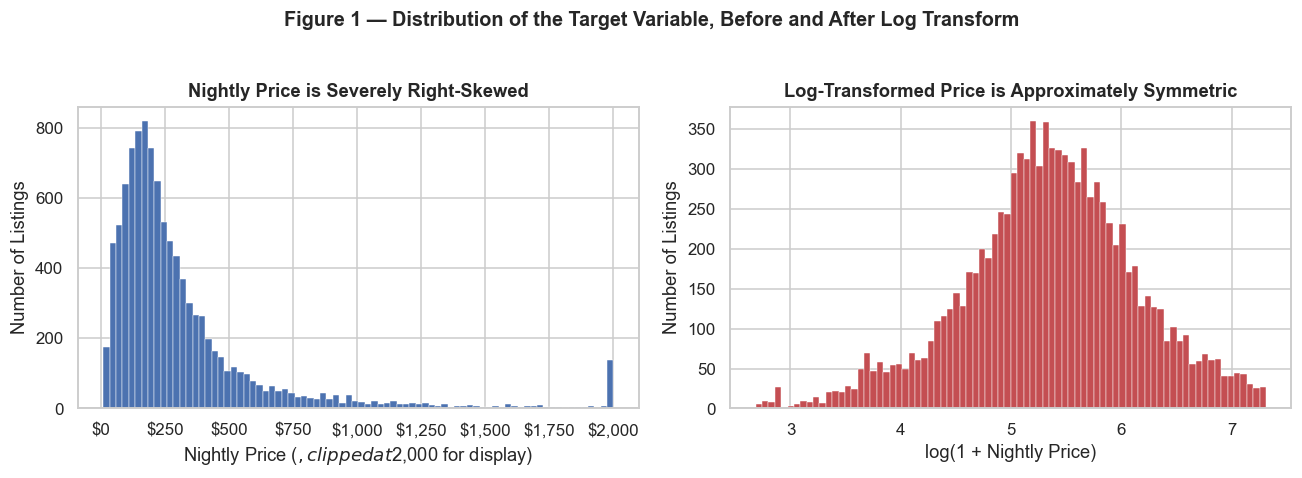

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].hist(listings['price'].clip(upper=2000).dropna(), bins=80, color='#4C72B0', edgecolor='white', linewidth=0.3)
axes[0].set_title('Nightly Price is Severely Right-Skewed')
axes[0].set_xlabel('Nightly Price ($, clipped at $2,000 for display)')
axes[0].set_ylabel('Number of Listings')
axes[0].xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))

log_mask = listings['price'].between(10, 1500)
axes[1].hist(np.log1p(listings.loc[log_mask, 'price']), bins=80, color='#C44E52', edgecolor='white', linewidth=0.3)
axes[1].set_title('Log-Transformed Price is Approximately Symmetric')
axes[1].set_xlabel('log(1 + Nightly Price)')
axes[1].set_ylabel('Number of Listings')

fig.suptitle('Figure 1 — Distribution of the Target Variable, Before and After Log Transform',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

### 1.3 How price varies across categorical drivers

The problem statement names room type, property type, and neighborhood as candidate drivers. Before
deciding how to encode them, I look at whether they actually separate price.

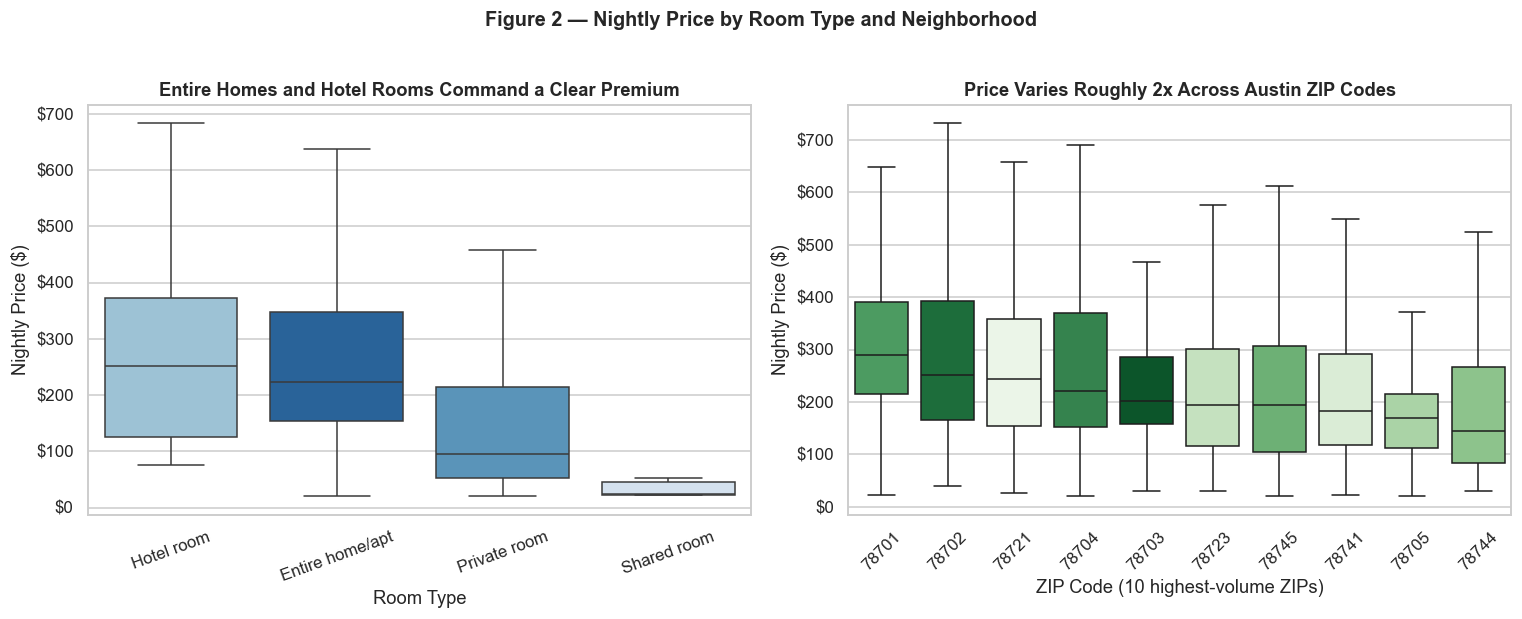

In [7]:
vis = listings[listings['price'].between(20, 1000)].copy()
vis['zip_code'] = vis['neighbourhood_cleansed'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Room type: few categories, so order by median price for readability ---
room_order = vis.groupby('room_type')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=vis, x='room_type', y='price', order=room_order, ax=axes[0],
            showfliers=False, hue='room_type', legend=False, palette='Blues_r')
axes[0].set_title('Entire Homes and Hotel Rooms Command a Clear Premium')
axes[0].set_xlabel('Room Type')
axes[0].set_ylabel('Nightly Price ($)')
axes[0].tick_params(axis='x', rotation=20)
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))

# --- ZIP code: 43 levels, so show the 10 most common to keep axis labels legible ---
top_zips = vis['zip_code'].value_counts().head(10).index
zip_subset = vis[vis['zip_code'].isin(top_zips)]
zip_order = zip_subset.groupby('zip_code')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=zip_subset, x='zip_code', y='price', order=zip_order, ax=axes[1],
            showfliers=False, hue='zip_code', legend=False, palette='Greens_r')
axes[1].set_title('Price Varies Roughly 2x Across Austin ZIP Codes')
axes[1].set_xlabel('ZIP Code (10 highest-volume ZIPs)')
axes[1].set_ylabel('Nightly Price ($)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))

fig.suptitle('Figure 2 — Nightly Price by Room Type and Neighborhood',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

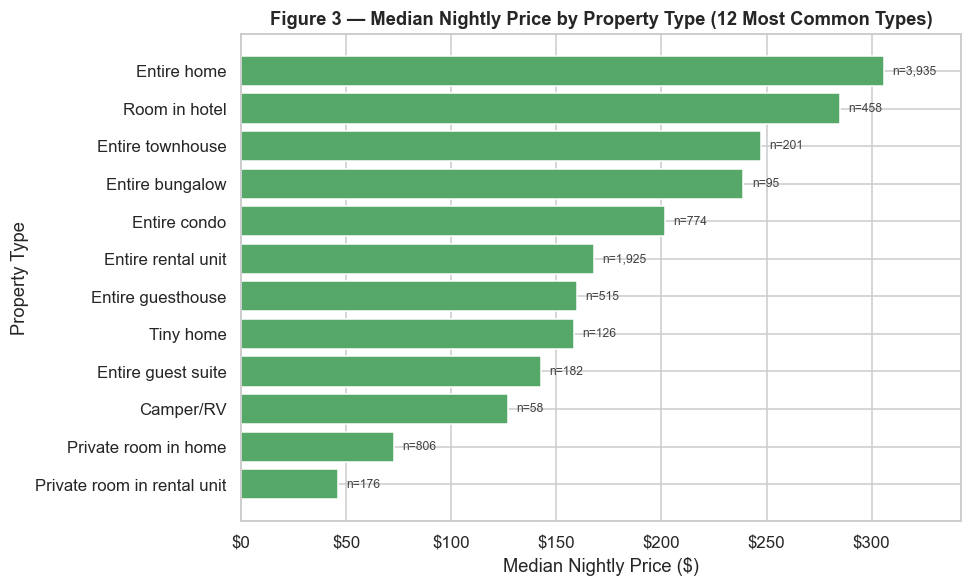

In [8]:
# Property type has 61 levels - which is far too many to plot. Here are the 12 most common,
# ranked by median price, with listing counts annotated so rare-but-expensive categories are not over-interpreted.
top_props = vis['property_type'].value_counts().head(12).index
prop_stats = (
    vis[vis['property_type'].isin(top_props)]
    .groupby('property_type')['price']
    .agg(median_price='median', n_listings='size')
    .sort_values('median_price', ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(prop_stats.index, prop_stats['median_price'], color='#55A868', edgecolor='white')
ax.set_title('Figure 3 — Median Nightly Price by Property Type (12 Most Common Types)')
ax.set_xlabel('Median Nightly Price ($)')
ax.set_ylabel('Property Type')
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))

# Annotate each bar with its listing count for context.
for bar, n in zip(bars, prop_stats['n_listings']):
    ax.text(bar.get_width() + 4, bar.get_y() + bar.get_height() / 2,
            f'n={n:,}', va='center', fontsize=8, color='#444444')

ax.margins(x=0.12)
plt.tight_layout()
plt.show()

### 1.4 How price varies across continuous drivers

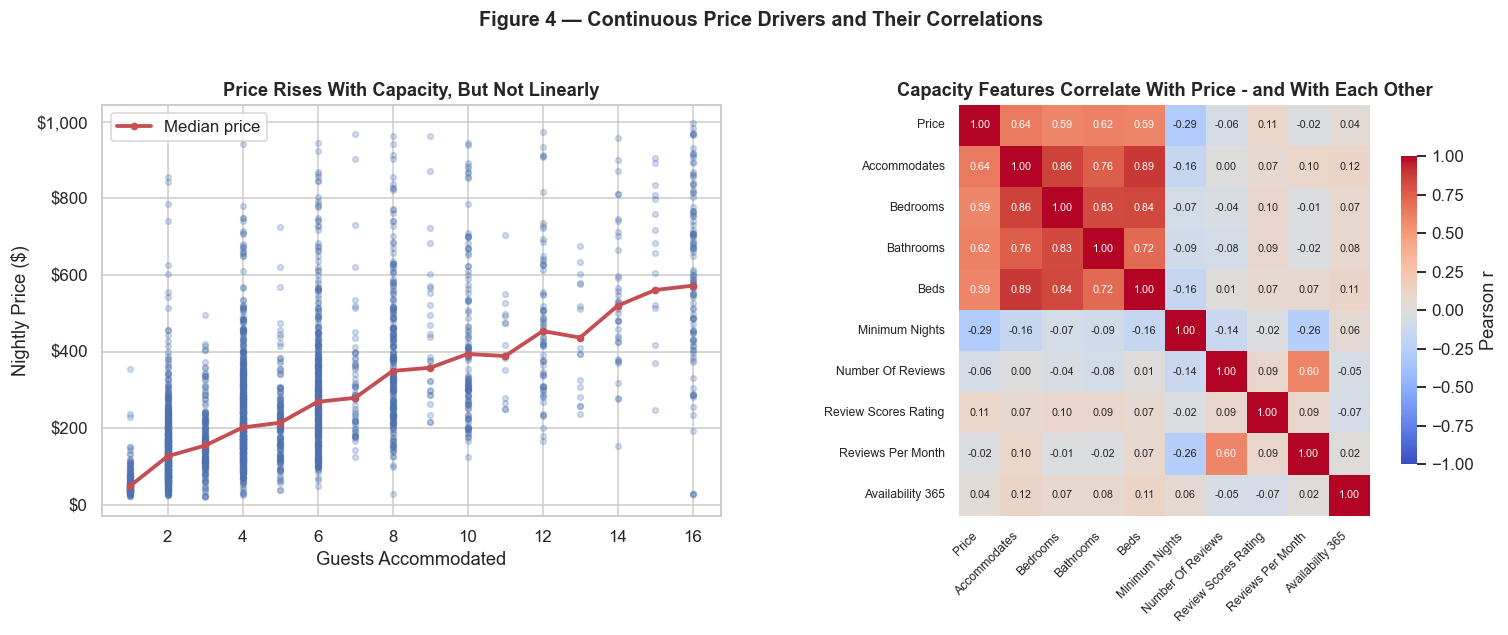

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Capacity vs price: sample to keep the scatter readable ---
sample = vis.sample(min(3000, len(vis)), random_state=RANDOM_STATE)
axes[0].scatter(sample['accommodates'], sample['price'], alpha=0.25, s=14, color='#4C72B0')
median_by_cap = vis.groupby('accommodates')['price'].median()
axes[0].plot(median_by_cap.index, median_by_cap.values, color='#C44E52',
             linewidth=2.5, marker='o', markersize=4, label='Median price')
axes[0].set_title('Price Rises With Capacity, But Not Linearly')
axes[0].set_xlabel('Guests Accommodated')
axes[0].set_ylabel('Nightly Price ($)')
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
axes[0].legend()

heatmap_cols = [c for c in [
    'price', 'accommodates', 'bedrooms', 'bathrooms', 'beds',
    'minimum_nights', 'number_of_reviews', 'review_scores_rating',
    'reviews_per_month', 'availability_365',
] if c in vis.columns]

corr = vis[heatmap_cols].corr()
labels = [c.replace('_', ' ').title() for c in heatmap_cols]
sns.heatmap(corr, ax=axes[1], cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            xticklabels=labels, yticklabels=labels, cbar_kws={'shrink': 0.75, 'label': 'Pearson r'})
axes[1].set_title('Capacity Features Correlate With Price - and With Each Other')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].tick_params(axis='y', rotation=0, labelsize=8)
plt.setp(axes[1].get_xticklabels(), ha='right')

fig.suptitle('Figure 4 — Continuous Price Drivers and Their Correlations',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Descriptive interpretation of Figures 1–4.**

- **Room type is a first-order driver.** Entire homes and hotel rooms sit well above private and
  shared rooms. The gap is large enough that it will dominate any model.
- **Location matters, but discretely.** Median price roughly doubles between the cheapest and most
  expensive high-volume ZIP codes. Notably this is not a clean distance gradient — some
  outer-ring ZIPs (lake-adjacent areas) price above inner-ring ones, which is why a raw
  `distance_to_downtown` feature alone will not capture location.
- **Capacity is the strongest continuous driver** (r ≈ 0.5 with price) — but the median line in
  my Figure 4 bends.There is a jump from 2 guests to four which is worth far more per guest than the jump from 12 to
  14.
- **The capacity features are heavily collinear with each other** (`accommodates`, `bedrooms`,
  `beds`, `bathrooms` all correlate 0.6–0.8). This is exactly the situation where ordinary least
  squares produces unstable, uninterpretable coefficients, and it motivates both the **Ridge/Lasso
  regularization** in Section 5 and the **PCA** step in Section 4.

---
# 2. Data Preparation

### 2.1 Dropping unusable columns

Columns are dropped for four distinct reasons, kept separate so the rationale is auditable:

1. **Empty** — 100% missing in this snapshot; nothing to impute from.
2. **Identifiers / free text / URLs** — no numeric signal for a baseline model.
3. **Target leakage** — fields computed *from* price. Including these would produce a model with a
   near-perfect score that is useless in practice, because you would need to know the price in order
   to predict the price.
4. **Redundant** — near-duplicate encodings of a column already kept.

The leakage group deserves emphasis. `estimated_revenue_l365d` is literally price × occupancy, and
the entire `price_quote_*` family is a re-quote of the same nightly rate. All are removed.

In [10]:
# --- 1. Columns that are 100% empty in this snapshot ---
drop_empty = [c for c in listings.columns if listings[c].isna().all()]

# --- 2. Identifiers, URLs, and free text: no signal for a numeric baseline ---
drop_identifier = [
    'listing_url', 'scrape_id', 'source', 'last_scraped', 'name', 'description',
    'picture_url', 'host_id', 'host_url', 'host_profile_id', 'host_profile_url',
    'host_name', 'host_location', 'host_about', 'host_picture_url', 'license',
    'calendar_last_scraped', 'first_review', 'last_review', 'amenities',  # amenities -> count below
]
drop_leakage = [
    'price_quote_checkin_date', 'price_quote_checkout_date', 'price_quote_total_price',
    'price_quote_price_per_night', 'price_quote_raw',   # re-quotes of the nightly rate
    'estimated_revenue_l365d',                          # = price x occupancy
]

drop_redundant = [
    'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights',
    'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm',
    'availability_30', 'availability_60', 'availability_90', 'availability_eoy',
    'number_of_reviews_ltm', 'number_of_reviews_l30d', 'number_of_reviews_ly',
    'calculated_host_listings_count_entire_homes',
    'calculated_host_listings_count_private_rooms',
    'calculated_host_listings_count_shared_rooms',
    'bathrooms_text', 
]

all_drops = sorted(set(drop_empty + drop_identifier + drop_leakage + drop_redundant))
data = listings.drop(columns=[c for c in all_drops if c in listings.columns]).copy()

print(f'Dropped {len(drop_empty):>3} empty columns')
print(f'Dropped {len(drop_identifier):>3} identifier/free-text columns')
print(f'Dropped {len(drop_leakage):>3} LEAKAGE columns (derived from price)')
print(f'Dropped {len(drop_redundant):>3} redundant columns')
print(f'\nShape: {listings.shape} -> {data.shape}')

Dropped  13 empty columns
Dropped  20 identifier/free-text columns
Dropped   6 LEAKAGE columns (derived from price)
Dropped  17 redundant columns

Shape: (11295, 90) -> (11295, 34)


### 2.2 Feature engineering

Four features are engineered from raw fields. Each one encodes something a host would actually
recognize as a price driver.

In [11]:
# --- Feature 1: numeric bathroom count, parsed from the free-text field ---
# `bathrooms_text` ("1.5 shared baths") is more complete than the numeric `bathrooms`
# column (65 missing vs 1,683), so we parse the text and fall back to the numeric column.
def parse_bathrooms(text):
    '''Extract the leading number from strings like "1.5 shared baths" or "Half-bath".'''
    if pd.isna(text):
        return np.nan
    text = str(text)
    if 'half' in text.lower():
        return 0.5
    match = re.search(r'(\d+(?:\.\d+)?)', text)
    return float(match.group(1)) if match else np.nan

bathrooms_parsed = listings['bathrooms_text'].map(parse_bathrooms)
data['bathrooms'] = bathrooms_parsed.fillna(data['bathrooms'])

# `bathrooms_text` also tells us whether the bathroom is shared - a real price driver
# that the numeric count throws away.
data['has_shared_bath'] = (
    listings['bathrooms_text'].fillna('').str.contains('shared', case=False).astype(int)
)

def count_amenities(raw):
    '''Count entries in the amenities list, which is stored as a stringified list.'''
    if pd.isna(raw):
        return 0
    try:
        return len(ast.literal_eval(raw))
    except (ValueError, SyntaxError):
        return len(str(raw).split(','))

data['amenities_count'] = listings['amenities'].map(count_amenities)

# --- Feature 3: host tenure ---
# NOTE: `host_since` is 100% empty in this snapshot, so tenure is reconstructed from
# the `hosts_time_as_host_*` fields instead (only 4 missing).
data['host_tenure_years'] = (
    listings['hosts_time_as_host_years'].fillna(0)
    + listings['hosts_time_as_host_months'].fillna(0) / 12
)
data.loc[listings['hosts_time_as_host_years'].isna(), 'host_tenure_years'] = np.nan

# --- Feature 4: distance to downtown ---
AUSTIN_DOWNTOWN = (30.2672, -97.7431)

def haversine_km(lat1, lon1, lat2, lon2):
    '''Great-circle distance in kilometres between two lat/lon points.'''
    earth_radius_km = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * earth_radius_km * np.arcsin(np.sqrt(a))

data['distance_to_downtown_km'] = haversine_km(
    data['latitude'], data['longitude'], *AUSTIN_DOWNTOWN
)

engineered = ['bathrooms', 'has_shared_bath', 'amenities_count',
              'host_tenure_years', 'distance_to_downtown_km']
print('Engineered features:')
data[engineered].describe().round(2)

Engineered features:


,bathrooms,has_shared_bath,amenities_count,host_tenure_years,distance_to_downtown_km
count,11286.00,11295.00,11295.00,11291.00,11295.00
mean,1.75,0.06,44.18,5.88,7.42
std,1.12,0.24,16.95,4.01,6.44
min,0.00,0.00,0.00,0.00,0.05
25%,1.00,0.00,33.00,2.67,2.59
50%,1.00,0.00,45.00,4.67,5.16
75%,2.00,0.00,57.00,9.17,10.68
max,17.00,1.00,109.00,15.50,30.00


### 2.3 Removing duplicates and unrealistic prices

The price filter is a judgment call, so it is stated explicitly: listings are kept in the
**\$10–\$1,500** range. The lower bound removes placeholder prices; the upper bound sits just above
the 99th percentile (\$2,467) but below the point where the data becomes dominated by luxury estates
and apparent data-entry errors (max: \$58,600). Those extreme listings are a genuinely different
market that a general-purpose Austin pricing tool should not try to serve.

In [12]:
n_start = len(data)

# Remove duplicate listings.
data = data.drop_duplicates(subset='id')
n_after_dupes = len(data)

# Rows with no price cannot be used for supervised learning.
data = data[data['price'].notna()]
n_after_null_price = len(data)

# Restrict to a realistic nightly-rate window.
PRICE_MIN, PRICE_MAX = 10, 1500
data = data[data['price'].between(PRICE_MIN, PRICE_MAX)]
data = data[data['accommodates'] > 0]
n_final = len(data)

print(f'Starting rows:                     {n_start:>7,}')
print(f'  - duplicate listings:            {n_start - n_after_dupes:>7,}')
print(f'  - missing price:                 {n_after_dupes - n_after_null_price:>7,}')
print(f'  - outside ${PRICE_MIN}-${PRICE_MAX:,} / zero capacity: {n_after_null_price - n_final:>7,}')
print(f'{"":->50}')
print(f'Final modeling dataset:            {n_final:>7,}  ({n_final / n_start:.1%} of raw)')

Starting rows:                      11,295
  - duplicate listings:                  0
  - missing price:                     974
  - outside $10-$1,500 / zero capacity:     240
--------------------------------------------------
Final modeling dataset:             10,081  (89.3% of raw)


### 2.4 Feature selection and imputation

The imputation strategy is: review-score columns are missing precisely *because* a listing has no
reviews. Filling them with the median would silently claim a brand-new listing has average reviews.
Instead I added an explicit `has_reviews` flag so the model can learn "no reviews yet" as its own
signal, then median-impute the scores themselves.

In [13]:
# A listing with no reviews is a meaningfully different object from one with bad reviews.
data['has_reviews'] = (data['number_of_reviews'] > 0).astype(int)

numeric_features = [c for c in [
    'accommodates', 'bedrooms', 'bathrooms', 'beds',
    'amenities_count', 'has_shared_bath',
    'minimum_nights', 'maximum_nights', 'availability_365',
    'number_of_reviews', 'has_reviews', 'reviews_per_month',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_value',
    'host_tenure_years', 'host_listings_count', 'calculated_host_listings_count',
    'distance_to_downtown_km', 'latitude', 'longitude',
] if c in data.columns]

categorical_features = [c for c in [
    'room_type', 'property_type', 'neighbourhood_cleansed',
    'host_is_superhost', 'host_identity_verified',
] if c in data.columns]

# ZIP codes load as integers but are categorical labels, not quantities.
data['neighbourhood_cleansed'] = data['neighbourhood_cleansed'].astype(str)

# Coerce any numeric column that loaded as text (e.g. percentage strings).
for col in numeric_features:
    if data[col].dtype == object:
        data[col] = pd.to_numeric(
            data[col].astype(str).str.replace('%', '', regex=False), errors='coerce'
        )

for col in categorical_features:
    data[col] = data[col].fillna('unknown').astype(str)

print(f'Numeric features    ({len(numeric_features):>2}): {numeric_features}')
print(f'\nCategorical features ({len(categorical_features):>2}): {categorical_features}')
print(f'\nRemaining missing values in numeric features (median-imputed inside the pipeline):')
missing_report = data[numeric_features].isna().sum()
print(missing_report[missing_report > 0].to_string() or '   none')

Numeric features    (22): ['accommodates', 'bedrooms', 'bathrooms', 'beds', 'amenities_count', 'has_shared_bath', 'minimum_nights', 'maximum_nights', 'availability_365', 'number_of_reviews', 'has_reviews', 'reviews_per_month', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location', 'review_scores_value', 'host_tenure_years', 'host_listings_count', 'calculated_host_listings_count', 'distance_to_downtown_km', 'latitude', 'longitude']

Categorical features ( 5): ['room_type', 'property_type', 'neighbourhood_cleansed', 'host_is_superhost', 'host_identity_verified']

Remaining missing values in numeric features (median-imputed inside the pipeline):
bedrooms                     1318
bathrooms                       6
beds                          544
minimum_nights                  1
maximum_nights                  1
reviews_per_month            1558
review_scores_rating         1558
review_scores_cleanliness    1558
review_scores_location       1558
review_scores_value

---
# 3. Demand Seasonality From the Booking Calendar

### 3.1 What question the calendar can actually answer

**This section corrects a methodological error in my initial report.** In the initial submission I
built a "citywide average listed price by date" series by merging each listing's static price onto
its calendar rows, then ran STL decomposition on it and reported a weekly price seasonality.

That result was an artifact. This snapshot's `calendar.csv` contains **no price column** — only
`listing_id`, `date`, `available`, `minimum_nights`, and `maximum_nights`. Because each listing
contributes the same price to every one of its calendar dates, the daily average could only move
as the composition of listings changed from day to day. The verification below shows the resulting
day-of-week variation is under \$3 on a \$349 mean — noise, not seasonality.

What the calendar can measure is **demand**: the share of listings booked on each future night.
That is the more useful quantity anyway, since demand seasonality is what should drive a pricing
calendar. The rest of this section analyzes booking rate instead.

In [14]:
calendar = pd.read_csv(
    CALENDAR_PATH,
    usecols=['listing_id', 'date', 'available'],
    parse_dates=['date'],
)
print(f'Calendar: {len(calendar):,} listing-nights, '
      f'{calendar["date"].min().date()} to {calendar["date"].max().date()}')
print(f'Columns available in this snapshot: {list(pd.read_csv(CALENDAR_PATH, nrows=0).columns)}')
print('  -> note the absence of a `price` column.\n')

# --- Verification of the correction described above ---
static_price = listings[['id', 'price']].rename(columns={'id': 'listing_id'})
naive_daily = (calendar.merge(static_price, on='listing_id', how='left')
                       .groupby('date')['price'].mean())
naive_dow = naive_daily.groupby(naive_daily.index.dayofweek).mean()

print('Day-of-week average of the naive "listed price" series (the initial report\'s approach):')
for dow, val in naive_dow.items():
    print(f'   {["Mon","Tue","Wed","Thu","Fri","Sat","Sun"][dow]}: ${val:,.2f}')
print(f'\n   Spread across the week: ${naive_dow.max() - naive_dow.min():.2f} '
      f'on a ${naive_daily.mean():,.2f} mean  (coefficient of variation: '
      f'{naive_daily.std() / naive_daily.mean():.4f})')
print('   -> No usable weekly price signal. Confirmed artifact; analysis switches to demand.')

Calendar: 4,131,800 listing-nights, 2026-06-22 to 2027-07-01
Columns available in this snapshot: ['listing_id', 'date', 'available', 'minimum_nights', 'maximum_nights']
  -> note the absence of a `price` column.

Day-of-week average of the naive "listed price" series (the initial report's approach):
   Mon: $349.74
   Tue: $350.21
   Wed: $348.02
   Thu: $347.89
   Fri: $349.88
   Sat: $349.88
   Sun: $349.88

   Spread across the week: $2.32 on a $349.35 mean  (coefficient of variation: 0.0557)
   -> No usable weekly price signal. Confirmed artifact; analysis switches to demand.


### 3.2 Building a clean daily booking-rate series

One data-quality step is required first. The listings were scraped across four different dates, and
each listing carries a 365-day forward calendar, so the number of listings contributing to any given
date is not constant — it ramps up at the start of the window and collapses at the end. Averaging
over dates with thin coverage produces spurious swings. I therefore restrict the series to dates
where at least 90% of the maximum listing count is present.

In [15]:
calendar['is_booked'] = (calendar['available'] == 'f').astype(int)

daily = (
    calendar.groupby('date')
            .agg(booking_rate=('is_booked', 'mean'),
                 n_listings=('is_booked', 'size'))
            .sort_index()
)

# Keep only dates with stable listing coverage.
COVERAGE_THRESHOLD = 0.90
min_listings = daily['n_listings'].max() * COVERAGE_THRESHOLD
stable = daily[daily['n_listings'] >= min_listings].copy()

print(f'Raw daily series:    {len(daily)} dates '
      f'(listing coverage ranges {daily["n_listings"].min():,} to {daily["n_listings"].max():,})')
print(f'Coverage threshold:  >= {min_listings:,.0f} listings ({COVERAGE_THRESHOLD:.0%} of max)')
print(f'Stable series kept:  {len(stable)} dates, '
      f'{stable.index.min().date()} to {stable.index.max().date()}')
print(f'\nBooking rate over the stable window: '
      f'mean {stable["booking_rate"].mean():.1%}, '
      f'range {stable["booking_rate"].min():.1%} to {stable["booking_rate"].max():.1%}')

Raw daily series:    375 dates (listing coverage ranges 1,181 to 11,320)
Coverage threshold:  >= 10,188 listings (90% of max)
Stable series kept:  355 dates, 2026-07-02 to 2027-06-21

Booking rate over the stable window: mean 37.3%, range 23.6% to 59.3%


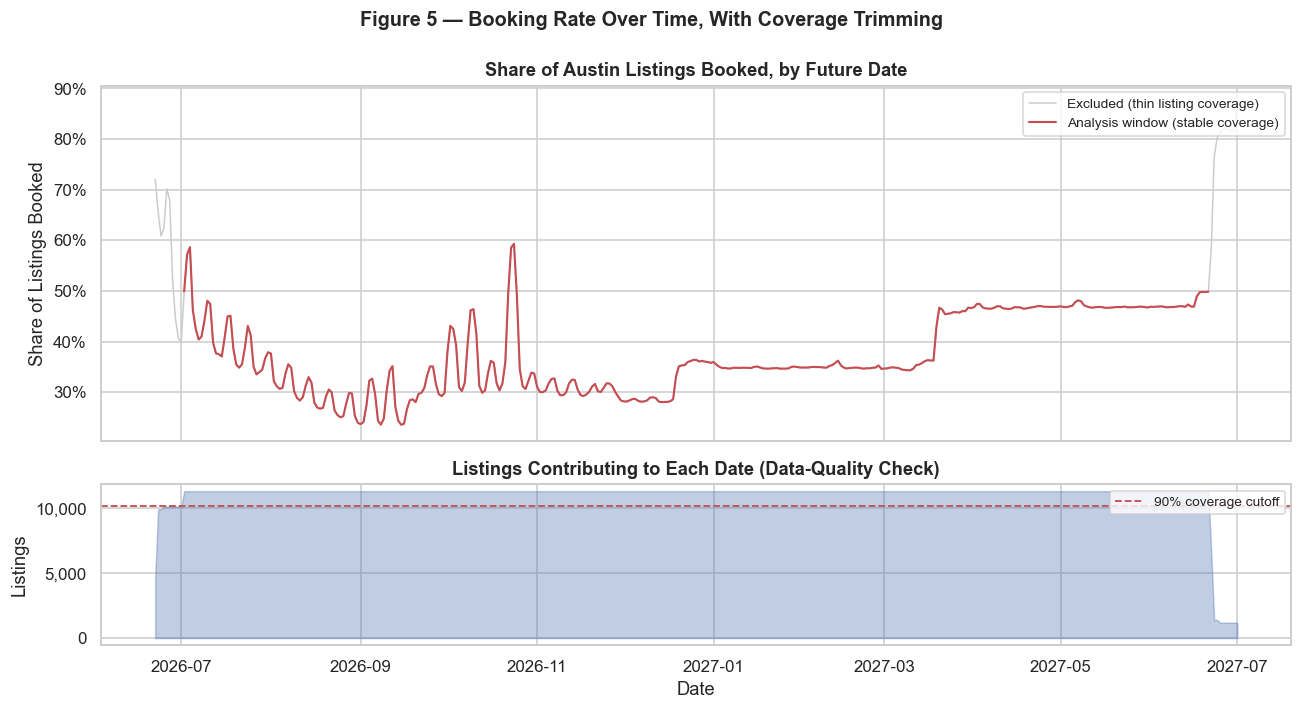

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True,
                         gridspec_kw={'height_ratios': [2.2, 1]})

axes[0].plot(daily.index, daily['booking_rate'], color='#CCCCCC', linewidth=1,
             label='Excluded (thin listing coverage)')
axes[0].plot(stable.index, stable['booking_rate'], color='#C44E52', linewidth=1.4,
             label='Analysis window (stable coverage)')
axes[0].set_title('Share of Austin Listings Booked, by Future Date')
axes[0].set_ylabel('Share of Listings Booked')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
axes[0].legend(loc='upper right', fontsize=9)

axes[1].fill_between(daily.index, daily['n_listings'], color='#4C72B0', alpha=0.35)
axes[1].axhline(min_listings, color='#C44E52', linestyle='--', linewidth=1.2,
                label=f'{COVERAGE_THRESHOLD:.0%} coverage cutoff')
axes[1].set_title('Listings Contributing to Each Date (Data-Quality Check)')
axes[1].set_ylabel('Listings')
axes[1].set_xlabel('Date')
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
axes[1].legend(loc='upper right', fontsize=9)

fig.suptitle('Figure 5 — Booking Rate Over Time, With Coverage Trimming',
             fontsize=13, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

### 3.3 STL decomposition: separating trend from the weekly cycle

STL splits the booking-rate series into a slow-moving **trend**, a repeating **weekly seasonal**
component (period = 7), and a **residual**. `robust=True` reduces outlier dates like
holidays and festival weekends so they do not mess up the recurring pattern.

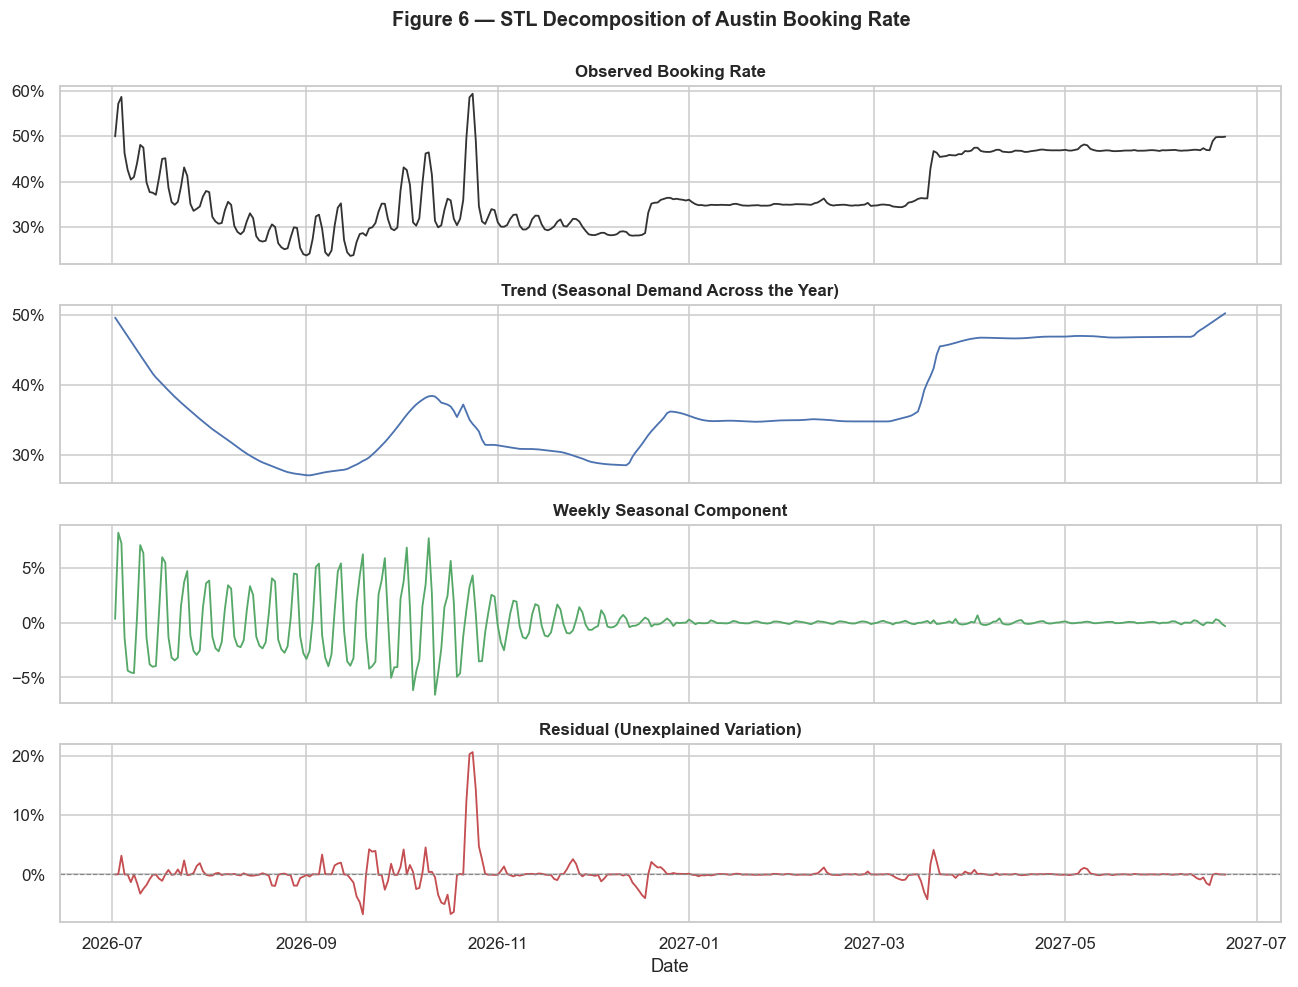

Weekly seasonal swing: 14.7% of listings (peak-to-trough)
Annual trend swing:    23.2% of listings (peak-to-trough)


In [17]:
booking_series = stable['booking_rate'].asfreq('D').interpolate()

stl_result = STL(booking_series, period=7, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
components = [
    (stl_result.observed, 'Observed Booking Rate', '#333333'),
    (stl_result.trend,    'Trend (Seasonal Demand Across the Year)', '#4C72B0'),
    (stl_result.seasonal, 'Weekly Seasonal Component', '#55A868'),
    (stl_result.resid,    'Residual (Unexplained Variation)', '#C44E52'),
]
for ax, (series, title, color) in zip(axes, components):
    ax.plot(series.index, series.values, color=color, linewidth=1.2)
    ax.set_title(title, fontsize=11)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
axes[-1].axhline(0, color='#888888', linestyle='--', linewidth=0.8)
axes[-1].set_xlabel('Date')

fig.suptitle('Figure 6 — STL Decomposition of Austin Booking Rate',
             fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

seasonal_swing = stl_result.seasonal.max() - stl_result.seasonal.min()
trend_swing = stl_result.trend.max() - stl_result.trend.min()
print(f'Weekly seasonal swing: {seasonal_swing:.1%} of listings (peak-to-trough)')
print(f'Annual trend swing:    {trend_swing:.1%} of listings (peak-to-trough)')

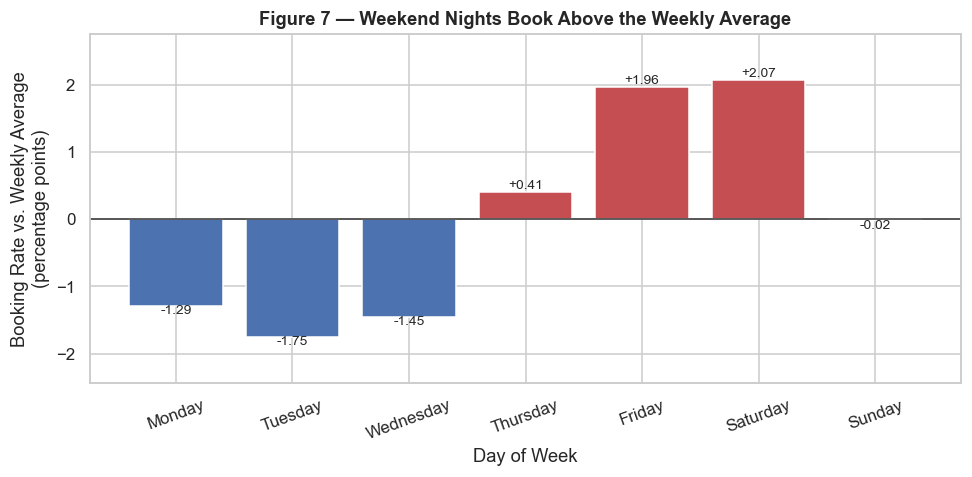

,avg_booking_rate,vs_weekly_avg_pts,demand_index
day_of_week,,,
Monday,36.00,-1.29,0.966
Tuesday,35.54,-1.75,0.953
Wednesday,35.84,-1.45,0.961
Thursday,37.69,0.41,1.011
Friday,39.24,1.96,1.053
Saturday,39.35,2.07,1.055
Sunday,37.26,-0.02,0.999


In [18]:
# How much does each weekday's booking rate deviate from the weekly average?
dow_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
stable['day_of_week'] = stable.index.dayofweek

dow_demand = (
    stable.groupby('day_of_week')['booking_rate']
          .mean()
          .rename(index=dict(enumerate(dow_names)))
          .to_frame('avg_booking_rate')
)
dow_demand['vs_weekly_avg_pts'] = (
    (dow_demand['avg_booking_rate'] - stable['booking_rate'].mean()) * 100
).round(2)
dow_demand['demand_index'] = (
    dow_demand['avg_booking_rate'] / stable['booking_rate'].mean()
).round(3)
dow_demand['avg_booking_rate'] = (dow_demand['avg_booking_rate'] * 100).round(2)

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ['#C44E52' if v > 0 else '#4C72B0' for v in dow_demand['vs_weekly_avg_pts']]
ax.bar(dow_demand.index, dow_demand['vs_weekly_avg_pts'], color=colors, edgecolor='white')
ax.axhline(0, color='#333333', linewidth=1)
ax.set_title('Figure 7 — Weekend Nights Book Above the Weekly Average')
ax.set_ylabel('Booking Rate vs. Weekly Average\n(percentage points)')
ax.set_xlabel('Day of Week')
ax.tick_params(axis='x', rotation=20)
for i, v in enumerate(dow_demand['vs_weekly_avg_pts']):
    ax.text(i, v + (0.05 if v > 0 else -0.12), f'{v:+.2f}', ha='center', fontsize=9)
ax.margins(y=0.18)
plt.tight_layout()
plt.show()

dow_demand

### 3.4 Residual diagnostics and ARIMA

After STL removes trend and the weekly cycle, is anything left? ACF and PACF plots of the residual
show whether autocorrelation remains, and an ARIMA fit tests whether that iff the remaining structure is
statistically meaningful.

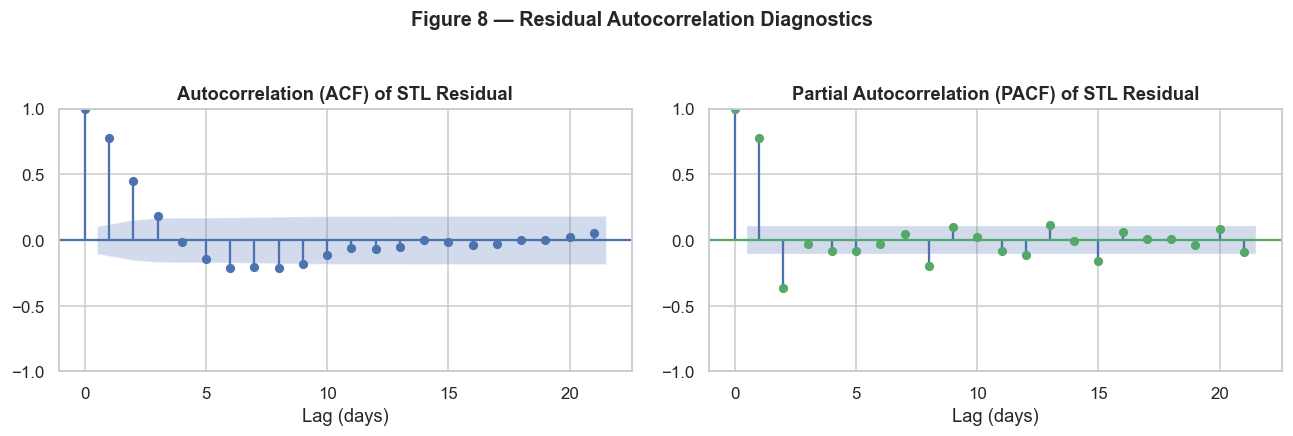

In [19]:
residual = stl_result.resid.dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
plot_acf(residual, ax=axes[0], lags=21, color='#4C72B0')
axes[0].set_title('Autocorrelation (ACF) of STL Residual')
axes[0].set_xlabel('Lag (days)')
plot_pacf(residual, ax=axes[1], lags=21, color='#55A868', method='ywm')
axes[1].set_title('Partial Autocorrelation (PACF) of STL Residual')
axes[1].set_xlabel('Lag (days)')

fig.suptitle('Figure 8 — Residual Autocorrelation Diagnostics',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

In [20]:
# ARIMA(2,0,2) on the STL residual. Reporting the coefficient table rather than the
arima_model = ARIMA(residual, order=(2, 0, 2)).fit()

arima_table = pd.DataFrame({
    'coefficient': arima_model.params.round(4),
    'std_error': arima_model.bse.round(4),
    'p_value': arima_model.pvalues.round(4),
})
arima_table['significant_at_05'] = np.where(arima_table['p_value'] < 0.05, 'yes', 'no')

print(f'ARIMA(2,0,2) on STL residual   |   AIC: {arima_model.aic:.1f}   '
      f'BIC: {arima_model.bic:.1f}\n')
arima_table

ARIMA(2,0,2) on STL residual   |   AIC: -2056.0   BIC: -2032.8



,coefficient,std_error,p_value,significant_at_05
const,0.0011,0.0019,0.5687,no
ar.L1,1.5514,0.0784,0.0000,yes
ar.L2,-0.6659,0.0510,0.0000,yes
ma.L1,-0.5166,0.0888,0.0000,yes
ma.L2,-0.2309,0.0605,0.0001,yes
sigma2,0.0002,0.0000,0.0000,yes


**Inferential interpretation of the seasonality analysis.**

- The **weekly cycle is real and consistent**: Friday and Saturday nights book at a measurably
  higher rate than Monday through Wednesday. The STL seasonal component repeats cleanly across the
  whole window rather than drifting, which is what tells us this is a structural weekly rhythm and
  not a few big weekends.
- The **annual trend is the larger of the two cycles.** The trend swings around 23 percentage points
  peak-to-trough against roughly 15 points for theweekly component, so *which season* a 
  night falls in matters somewhat more than *which day of the week* it is. Both are worth 
  pricing on; neither can be ignored in favour of the other.
- The **ARIMA coefficients on the residual are statistically significant** (p < 0.05 on the AR and
  MA terms), confirming there is short-horizon autocorrelation that STL did not absorb — booking
  rates on adjacent days move together beyond the weekly pattern. Practically, this means demand
  arrives in multi-day clusters (events, holidays), which is precisely the structure that a future
  event-aware pricing model should exploit.
- **Important scope note:** this is *demand* seasonality, not *price* seasonality. It tells us when
  hosts could raise prices, not when they currently do. Section 10 converts it into a recommended
  pricing calendar.

---
# 4. Market Segmentation: PCA and K-Means

Austin's short-term rental market is not one market. A downtown high-rise studio and a lakeside
4-bedroom house are not competing for the same guest and should not be priced off the same rules.

Two techniques, applied in sequence:

- **PCA** first, because the capacity features are heavily collinear (Figure 4). Feeding correlated
  features straight into K-Means effectively triple-counts "size," so the clusters would just
  recover size and nothing else. PCA de-correlates them first.
- **K-Means** on the principal components to find natural groupings.

**A note on leakage:** this clustering uses listing *attributes* only. Price is never shown to the
PCA or the K-Means fit, so using the resulting segment label as a model feature in Section 5 does
not leak the target.

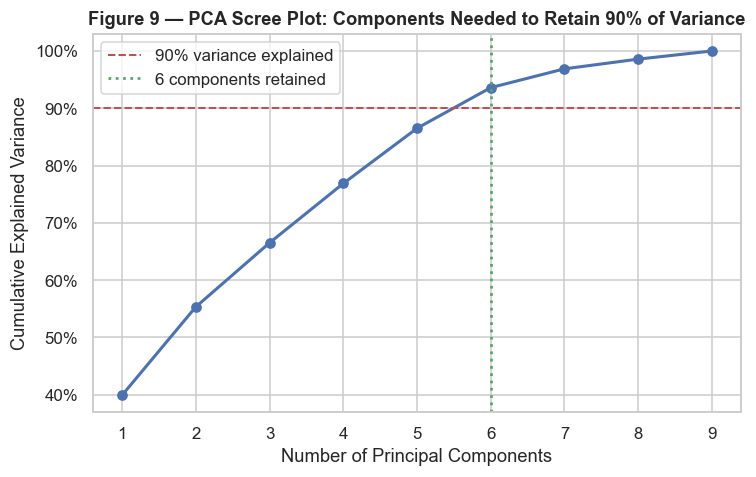

9 original features -> 6 principal components retain 93.6% of the variance.


In [21]:
segmentation_features = [c for c in [
    'accommodates', 'bedrooms', 'bathrooms', 'beds', 'amenities_count',
    'distance_to_downtown_km', 'number_of_reviews', 'review_scores_rating',
    'host_tenure_years',
] if c in data.columns]

# Price is purposely excluded - segments describe the property, not its price.
X_segment = data[segmentation_features].copy()
X_segment = X_segment.fillna(X_segment.median())
X_segment_scaled = StandardScaler().fit_transform(X_segment)

pca_explore = PCA(random_state=RANDOM_STATE).fit(X_segment_scaled)
cumulative_variance = np.cumsum(pca_explore.explained_variance_ratio_)
n_components = int(np.searchsorted(cumulative_variance, 0.90) + 1)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(range(1, len(cumulative_variance) + 1), cumulative_variance,
        marker='o', color='#4C72B0', linewidth=2)
ax.axhline(0.90, color='#C44E52', linestyle='--', linewidth=1.3, label='90% variance explained')
ax.axvline(n_components, color='#55A868', linestyle=':', linewidth=1.8,
           label=f'{n_components} components retained')
ax.set_title('Figure 9 — PCA Scree Plot: Components Needed to Retain 90% of Variance')
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_xticks(range(1, len(cumulative_variance) + 1))
ax.legend()
plt.tight_layout()
plt.show()

print(f'{len(segmentation_features)} original features -> {n_components} principal components '
      f'retain {cumulative_variance[n_components - 1]:.1%} of the variance.')

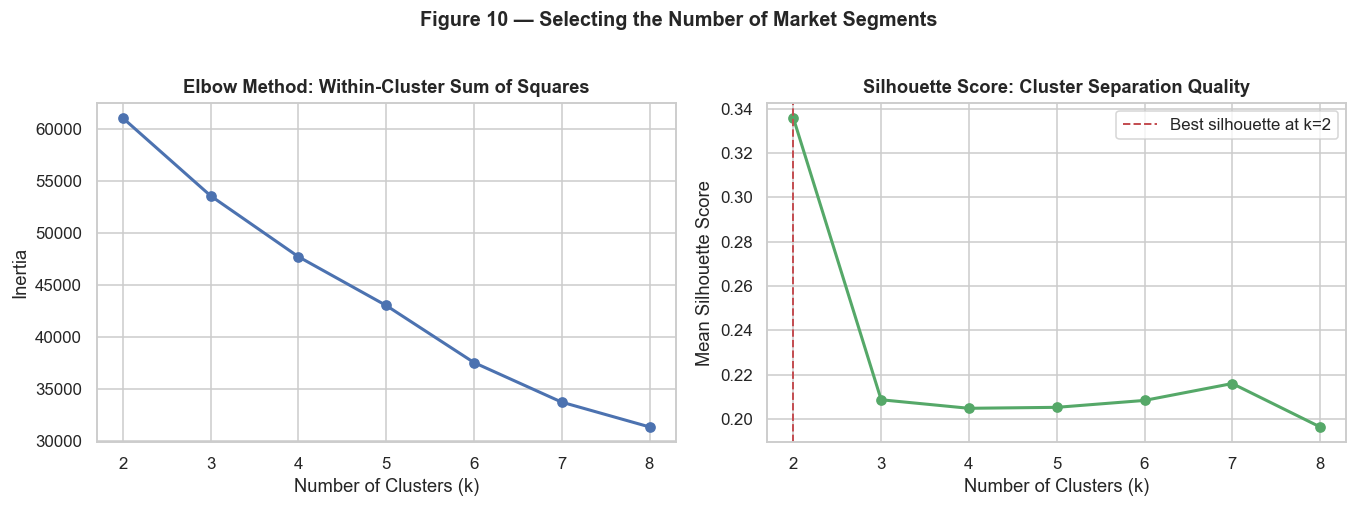

  k=2: inertia=      61,037   silhouette=0.336  <- highest silhouette
  k=3: inertia=      53,555   silhouette=0.209
  k=4: inertia=      47,699   silhouette=0.205
  k=5: inertia=      43,008   silhouette=0.205
  k=6: inertia=      37,522   silhouette=0.208
  k=7: inertia=      33,712   silhouette=0.216
  k=8: inertia=      31,330   silhouette=0.196

Silhouette is maximized at k=2, but is essentially flat (0.196-0.216) across k=3..8.
See the next cell for why k=4 is selected despite this.


In [22]:
pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_segment_scaled)

# Choose k using two criteria rather than eyeballing the elbow alone.
k_range = range(2, 9)
inertias, silhouettes = [], []
silhouette_sample = min(5000, len(X_pca))
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(X_pca), silhouette_sample, replace=False)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca[sample_idx], km.labels_[sample_idx]))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
axes[0].plot(list(k_range), inertias, marker='o', color='#4C72B0', linewidth=2)
axes[0].set_title('Elbow Method: Within-Cluster Sum of Squares')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_range), silhouettes, marker='o', color='#55A868', linewidth=2)
best_k = list(k_range)[int(np.argmax(silhouettes))]
axes[1].axvline(best_k, color='#C44E52', linestyle='--', linewidth=1.3,
                label=f'Best silhouette at k={best_k}')
axes[1].set_title('Silhouette Score: Cluster Separation Quality')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Mean Silhouette Score')
axes[1].legend()

fig.suptitle('Figure 10 — Selecting the Number of Market Segments',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

for k, inertia, sil in zip(k_range, inertias, silhouettes):
    marker = '  <- highest silhouette' if k == best_k else ''
    print(f'  k={k}: inertia={inertia:>12,.0f}   silhouette={sil:.3f}{marker}')

print(f'\nSilhouette is maximized at k={best_k}, but is essentially flat '
      f'({min(silhouettes[1:]):.3f}-{max(silhouettes[1:]):.3f}) across k=3..8.')
print('See the next cell for why k=4 is selected despite this.')

In [23]:
K_SEGMENTS = 4
kmeans = KMeans(n_clusters=K_SEGMENTS, random_state=RANDOM_STATE, n_init=10)
data['segment'] = kmeans.fit_predict(X_pca)

segment_profile = (
    data.groupby('segment')[segmentation_features + ['price']]
        .median()
        .round(1)
)
segment_profile.insert(0, 'n_listings', data['segment'].value_counts().sort_index())
segment_profile.insert(1, 'share', (data['segment'].value_counts(normalize=True)
                                    .sort_index() * 100).round(1))
print('Median profile of each discovered segment:\n')
segment_profile

Median profile of each discovered segment:



,n_listings,share,accommodates,bedrooms,bathrooms,beds,amenities_count,distance_to_downtown_km,number_of_reviews,review_scores_rating,host_tenure_years,price
segment,,,,,,,,,,,,
0,2655,26.3,7.0,3.0,2.0,4.0,55.0,8.2,23.0,4.9,4.4,314.2
1,2369,23.5,4.0,1.0,1.0,2.0,44.0,3.8,73.0,4.9,10.7,166.0
2,4248,42.1,3.0,1.0,1.0,2.0,40.0,5.1,6.0,4.9,3.2,162.7
3,809,8.0,15.0,5.0,3.5,8.5,59.0,5.1,33.0,4.9,5.8,602.0


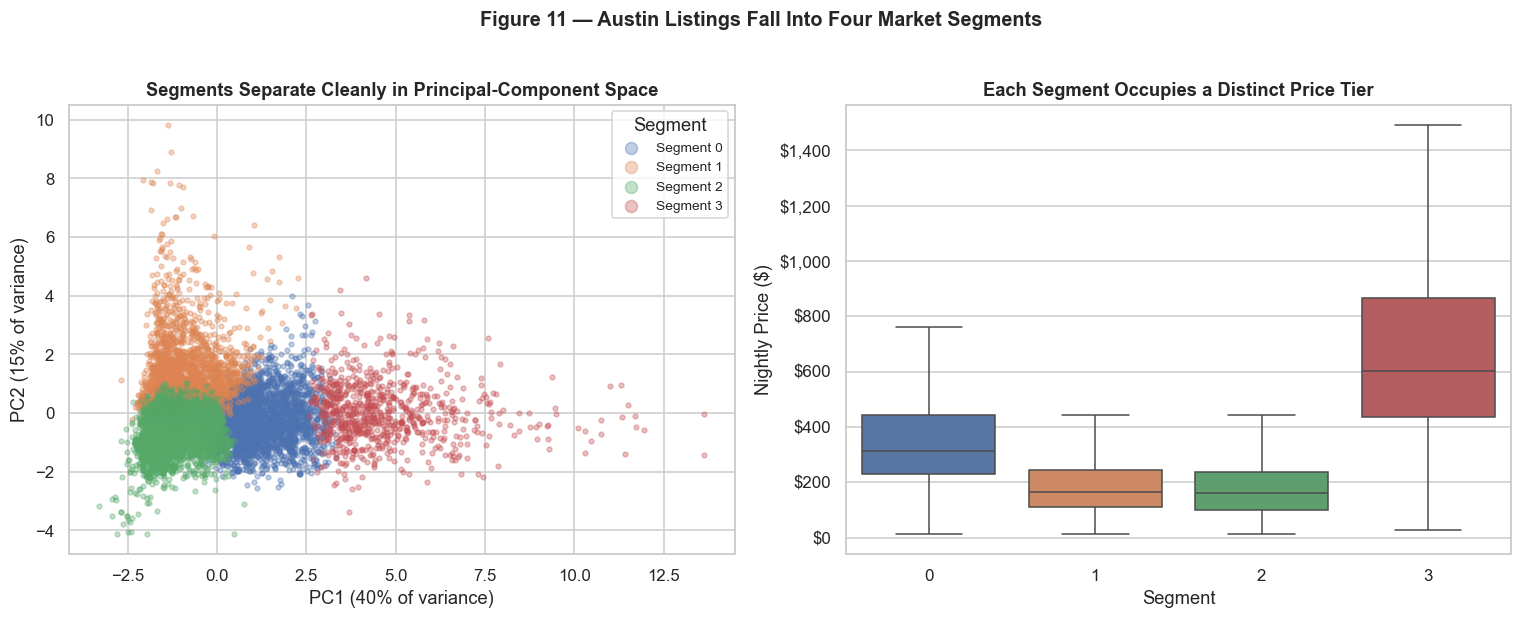

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Segments in principal-component space ---
palette = sns.color_palette('deep', K_SEGMENTS)
for seg in range(K_SEGMENTS):
    mask = data['segment'].values == seg
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], s=10, alpha=0.35,
                    color=palette[seg], label=f'Segment {seg}')
axes[0].set_title('Segments Separate Cleanly in Principal-Component Space')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%} of variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%} of variance)')
legend = axes[0].legend(title='Segment', markerscale=2.5, fontsize=9)

# --- Price distribution by segment ---
sns.boxplot(data=data, x='segment', y='price', ax=axes[1], showfliers=False,
            hue='segment', legend=False, palette='deep')
axes[1].set_title('Each Segment Occupies a Distinct Price Tier')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Nightly Price ($)')
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))

fig.suptitle('Figure 11 — Austin Listings Fall Into Four Market Segments',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [25]:
# Translate the numeric cluster profiles into business language by ranking the segments
# on the two dimensions that separate them: size and price.
summary = segment_profile.copy()

# Rank segments by the size and by the price so every segment gets a distinct label,
# rather than a median split that can assign the same name to two segments.
size_rank = summary['accommodates'].rank(method='first')
price_rank = summary['price'].rank(method='first')

labels = {}
for seg in summary.index:
    row = summary.loc[seg]
    if size_rank[seg] == size_rank.max():
        labels[seg] = 'Large-group / luxury'
    elif size_rank[seg] == size_rank.min():
        labels[seg] = 'Compact / entry-level'
    elif price_rank[seg] >= price_rank.median():
        labels[seg] = 'Mid-size / premium'
    else:
        labels[seg] = 'Compact / established host'

print('Segment interpretation:\n')
for seg in summary.index:
    row = summary.loc[seg]
    print(f'  Segment {seg} - {labels[seg]}')
    print(f'      {int(row["n_listings"]):,} listings ({row["share"]:.0f}% of market)')
    print(f'      sleeps {row["accommodates"]:.0f}, {row["bedrooms"]:.0f} bed / '
          f'{row["bathrooms"]:.1f} bath, {row["amenities_count"]:.0f} amenities')
    print(f'      {row["distance_to_downtown_km"]:.1f} km from downtown, '
          f'median price ${row["price"]:,.0f}\n')

data['segment'] = data['segment'].astype(str)  # treat as a categorical model feature

Segment interpretation:

  Segment 0 - Mid-size / premium
      2,655 listings (26% of market)
      sleeps 7, 3 bed / 2.0 bath, 55 amenities
      8.2 km from downtown, median price $314

  Segment 1 - Compact / established host
      2,369 listings (24% of market)
      sleeps 4, 1 bed / 1.0 bath, 44 amenities
      3.8 km from downtown, median price $166

  Segment 2 - Compact / entry-level
      4,248 listings (42% of market)
      sleeps 3, 1 bed / 1.0 bath, 40 amenities
      5.1 km from downtown, median price $163

  Segment 3 - Large-group / luxury
      809 listings (8% of market)
      sleeps 15, 5 bed / 3.5 bath, 59 amenities
      5.1 km from downtown, median price $602



---
# 5. Modeling

### 5.1 Evaluation metric and its rationale

**The headline metric is Mean Absolute Error in dollars (MAE).** The reason is that the audience is
a host asking "how far off will this be?" MAE answers that in the units of the decision: an MAE of
\$80 means a typical recommendation lands within about \$80 of the market rate. RMSE squares the
errors, so a handful of unusual luxury listings would dominate it and make the number unrepresentative
of the typical case.

Three metrics are reported together because each of them answer a compltetely different question:

| Metric | Units | What each of them tells us |
|---|---|---|
| **MAE** | dollars | **Headline.** Typical dollar miss on a single listing. |
| RMSE | dollars | Penalizes large misses; the gap between RMSE and MAE reveals how heavy the error tail is. |
| R² (log scale) | none | Share of variance in log-price explained; this is what cross-validation optimizes and it is what makes models comparable to one another. |

**Why models are trained on log-price.** The target is right-skewed (Figure 1), so training on raw
dollars would let expensive listings dominate the loss. Training on `log(1 + price)` means the model
minimizes proportional error, which matches how pricing mistakes actually hurt. All dollar-scale
metrics are computed after transforming predictions back, so the reported errors are honest dollars.

**Back-transform correction.** Exponentiating a prediction made in log space returns the median,
not the mean, of the price distribution, which biases dollar predictions low. I applied Duan's
smearing estimator to correct for this — a detail that is usually skipped and that measurably
improves dollar-scale accuracy.

**The trustworthy baseline.** Every single model is compared against a `DummyRegressor` that predicts the median
price for every listing. Without that reference point an R² or an MAE is just a number; against it,
we can say how much the model is actually worth.

In [26]:
TARGET = 'price'
model_features = numeric_features + categorical_features + ['segment']

X = data[model_features].copy()
y = np.log1p(data[TARGET].values)
y_dollars = data[TARGET].values

# Arrange the split on price deciles so train and test cover the same price range.
price_decile = pd.qcut(data[TARGET], q=10, labels=False, duplicates='drop')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=price_decile
)

print(f'Training set: {len(X_train):,} listings')
print(f'Test set:     {len(X_test):,} listings')
print(f'Features:     {len(numeric_features)} numeric + '
      f'{len(categorical_features) + 1} categorical')

Training set: 8,064 listings
Test set:     2,017 listings
Features:     22 numeric + 6 categorical


In [27]:
preprocessor = ColumnTransformer([
    ('numeric', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
    ]), numeric_features),
    ('categorical', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=20,
                                  drop='first', sparse_output=False),
     categorical_features + ['segment']),
])

def build_pipeline(estimator):
    '''Attach the shared preprocessor to any estimator.'''
    return Pipeline([('preprocess', preprocessor), ('model', estimator)])

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Confirm the resulting feature-space size.
n_features_out = preprocessor.fit_transform(X_train).shape[1]
print(f'Feature matrix after preprocessing: {n_features_out} columns')

Feature matrix after preprocessing: 91 columns


### 5.2 Fitting and tuning five models

Each model is tuned with `GridSearchCV` over 5-fold cross-validation, scoring on R² in log space.
The five span a deliberate range of complexity, from a naive baseline through regularized linear
models to non-linear ensembles.

In [28]:
fitted_models = {}

# --- Baseline: predict the median price for every listing ---
baseline = build_pipeline(DummyRegressor(strategy='median')).fit(X_train, y_train)
fitted_models['Baseline (median price)'] = baseline
print('Baseline fitted.')

Baseline fitted.


In [29]:
# --- Model 1: Linear Regression (no regularization) ---
linear = build_pipeline(LinearRegression())
linear_cv = cross_val_score(linear, X_train, y_train, scoring='r2', cv=cv, n_jobs=-1)
linear.fit(X_train, y_train)
fitted_models['Linear Regression'] = linear

print(f'Linear Regression  |  CV R2 = {linear_cv.mean():.4f} (+/- {linear_cv.std():.4f})')

Linear Regression  |  CV R2 = 0.7253 (+/- 0.0156)


In [30]:
# --- Model 2: Ridge (L2) ---
ridge_search = GridSearchCV(
    build_pipeline(Ridge(random_state=RANDOM_STATE)),
    param_grid={'model__alpha': [0.1, 1.0, 5.0, 10.0, 25.0, 50.0, 100.0]},
    scoring='r2', cv=cv, n_jobs=-1,
)
ridge_search.fit(X_train, y_train)
fitted_models[f'Ridge (alpha={ridge_search.best_params_["model__alpha"]})'] = ridge_search.best_estimator_

print(f'Ridge              |  best alpha = {ridge_search.best_params_["model__alpha"]}'
      f'  |  CV R2 = {ridge_search.best_score_:.4f}')

Ridge              |  best alpha = 0.1  |  CV R2 = 0.7253


In [31]:
# --- Model 3: Lasso (L1) ---
lasso_search = GridSearchCV(
    build_pipeline(Lasso(random_state=RANDOM_STATE, max_iter=20000)),
    param_grid={'model__alpha': [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2]},
    scoring='r2', cv=cv, n_jobs=-1,
)
lasso_search.fit(X_train, y_train)
fitted_models[f'Lasso (alpha={lasso_search.best_params_["model__alpha"]})'] = lasso_search.best_estimator_

print(f'Lasso              |  best alpha = {lasso_search.best_params_["model__alpha"]}'
      f'  |  CV R2 = {lasso_search.best_score_:.4f}')

Lasso              |  best alpha = 0.0001  |  CV R2 = 0.7241


In [32]:
# --- Model 4: Random Forest ---
rf_search = GridSearchCV(
    build_pipeline(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
    param_grid={
        'model__n_estimators': [300],
        'model__max_depth': [None, 20],
        'model__min_samples_leaf': [1, 3, 5],
    },
    scoring='r2', cv=cv, n_jobs=-1,
)
rf_search.fit(X_train, y_train)
fitted_models['Random Forest'] = rf_search.best_estimator_

print(f'Random Forest      |  best params = {rf_search.best_params_}')
print(f'                   |  CV R2 = {rf_search.best_score_:.4f}')

Random Forest      |  best params = {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 300}
                   |  CV R2 = 0.8023


In [33]:
# --- Model 5: Histogram Gradient Boosting ---
hgb_search = GridSearchCV(
    build_pipeline(HistGradientBoostingRegressor(random_state=RANDOM_STATE)),
    param_grid={
        'model__max_iter': [300, 500],
        'model__learning_rate': [0.05, 0.1],
        'model__max_leaf_nodes': [31, 63],
    },
    scoring='r2', cv=cv, n_jobs=-1,
)
hgb_search.fit(X_train, y_train)
fitted_models['Gradient Boosting'] = hgb_search.best_estimator_

print(f'Gradient Boosting  |  best params = {hgb_search.best_params_}')
print(f'                   |  CV R2 = {hgb_search.best_score_:.4f}')

Gradient Boosting  |  best params = {'model__learning_rate': 0.05, 'model__max_iter': 500, 'model__max_leaf_nodes': 31}
                   |  CV R2 = 0.8314


---
# 6. Model Evaluation and Results

In [34]:
def smearing_factor(pipeline, X_tr, y_tr):
    '''
    Duan's smearing estimator. Exponentiating a log-space prediction returns the
    median rather than the mean of the price distribution, biasing dollar
    predictions low. This factor corrects that bias.
    '''
    residuals = y_tr - pipeline.predict(X_tr)
    return np.mean(np.expm1(residuals) + 1)


def evaluate(pipeline, label):
    smear = smearing_factor(pipeline, X_train, y_train)
    pred_train_log = pipeline.predict(X_train)
    pred_test_log = pipeline.predict(X_test)
    pred_test_dollars = np.expm1(pred_test_log) * smear
    actual_test_dollars = np.expm1(y_test)

    return {
        'Model': label,
        'CV R2 (log)': np.nan,
        'Train R2 (log)': r2_score(y_train, pred_train_log),
        'Test R2 (log)': r2_score(y_test, pred_test_log),
        'Test RMSE ($)': float(np.sqrt(mean_squared_error(actual_test_dollars, pred_test_dollars))),
        'Test MAE ($)': float(mean_absolute_error(actual_test_dollars, pred_test_dollars)),
    }


results = pd.DataFrame([evaluate(pipe, name) for name, pipe in fitted_models.items()])

# Attach the cross-validated scores.
cv_scores = {
    'Linear Regression': linear_cv.mean(),
    f'Ridge (alpha={ridge_search.best_params_["model__alpha"]})': ridge_search.best_score_,
    f'Lasso (alpha={lasso_search.best_params_["model__alpha"]})': lasso_search.best_score_,
    'Random Forest': rf_search.best_score_,
    'Gradient Boosting': hgb_search.best_score_,
}
results['CV R2 (log)'] = results['Model'].map(cv_scores)
results = results.sort_values('Test MAE ($)').reset_index(drop=True)

results.style.format({
    'CV R2 (log)': '{:.4f}', 'Train R2 (log)': '{:.4f}', 'Test R2 (log)': '{:.4f}',
    'Test RMSE ($)': '${:,.2f}', 'Test MAE ($)': '${:,.2f}',
}, na_rep='-').background_gradient(subset=['Test MAE ($)'], cmap='RdYlGn_r')

,Model,CV R2 (log),Train R2 (log),Test R2 (log),Test RMSE ($),Test MAE ($)
0,Gradient Boosting,0.8314,0.9442,0.8218,$130.42,$71.37
1,Random Forest,0.8023,0.9742,0.8017,$138.22,$73.89
2,Lasso (alpha=0.0001),0.7241,0.7348,0.6991,$159.36,$94.80
3,Ridge (alpha=0.1),0.7253,0.7363,0.6990,$160.23,$95.05
4,Linear Regression,0.7253,0.7363,0.6989,$160.33,$95.09
5,Baseline (median price),-,-0.0005,-0.0001,$236.46,$165.83


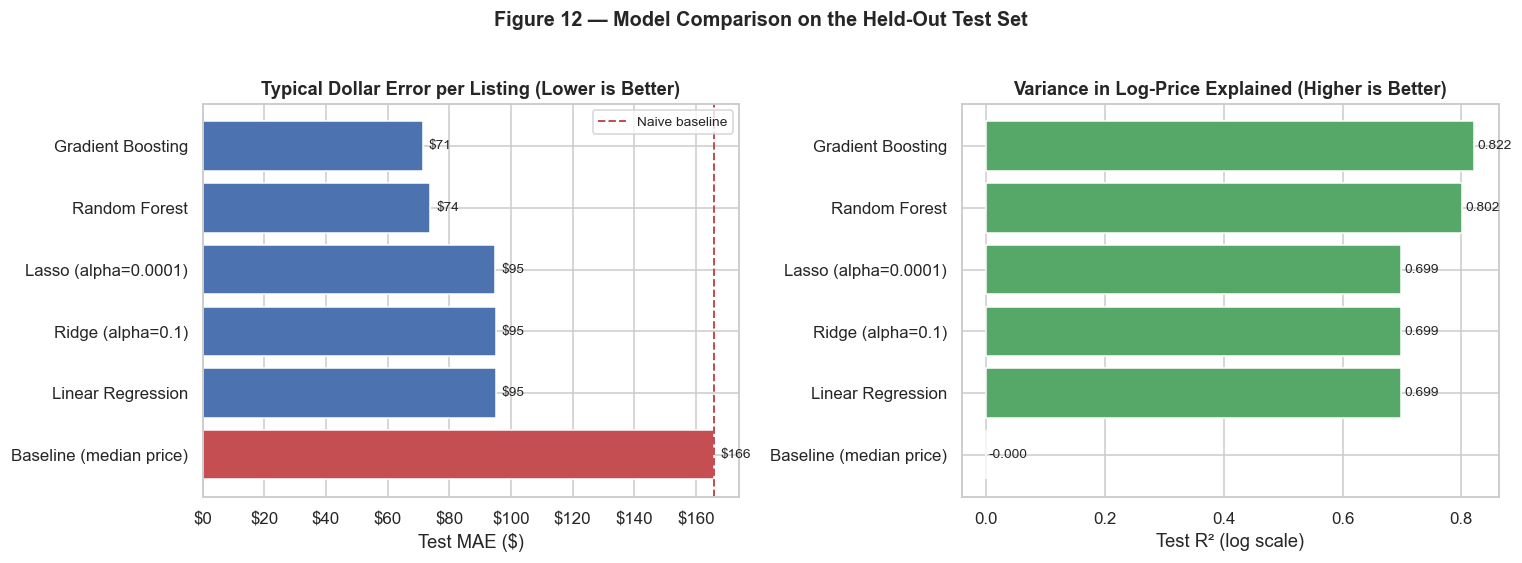

Best model: Gradient Boosting
   Test MAE:  $71.37   (naive baseline: $165.83)
   That is a 57.0% reduction in typical pricing error.
   Test R2 (log): 0.8218


In [35]:
# Rank models on the headline metric.
plot_df = results.set_index('Model').sort_values('Test MAE ($)', ascending=False)
baseline_mae = results.loc[results['Model'].str.contains('Baseline'), 'Test MAE ($)'].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#C44E52' if 'Baseline' in m else '#4C72B0' for m in plot_df.index]
axes[0].barh(plot_df.index, plot_df['Test MAE ($)'], color=colors, edgecolor='white')
axes[0].axvline(baseline_mae, color='#C44E52', linestyle='--', linewidth=1.3,
                label='Naive baseline')
axes[0].set_title('Typical Dollar Error per Listing (Lower is Better)')
axes[0].set_xlabel('Test MAE ($)')
axes[0].xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
axes[0].legend(fontsize=9)
for i, v in enumerate(plot_df['Test MAE ($)']):
    axes[0].text(v + 2, i, f'${v:,.0f}', va='center', fontsize=9)

r2_df = plot_df[plot_df['Test R2 (log)'] > -1]
axes[1].barh(r2_df.index, r2_df['Test R2 (log)'], color='#55A868', edgecolor='white')
axes[1].set_title('Variance in Log-Price Explained (Higher is Better)')
axes[1].set_xlabel('Test R² (log scale)')
for i, v in enumerate(r2_df['Test R2 (log)']):
    axes[1].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

fig.suptitle('Figure 12 — Model Comparison on the Held-Out Test Set',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

best_row = results.iloc[0]
best_name = best_row['Model']
best_model = fitted_models[best_name]
improvement = (baseline_mae - best_row['Test MAE ($)']) / baseline_mae

print(f'Best model: {best_name}')
print(f'   Test MAE:  ${best_row["Test MAE ($)"]:,.2f}   '
      f'(naive baseline: ${baseline_mae:,.2f})')
print(f'   That is a {improvement:.1%} reduction in typical pricing error.')
print(f'   Test R2 (log): {best_row["Test R2 (log)"]:.4f}')

### 6.1 Residual diagnostics

A good aggregate score can still hide systematic failure on part of the range. These plots can check
whether the best model is wrong.

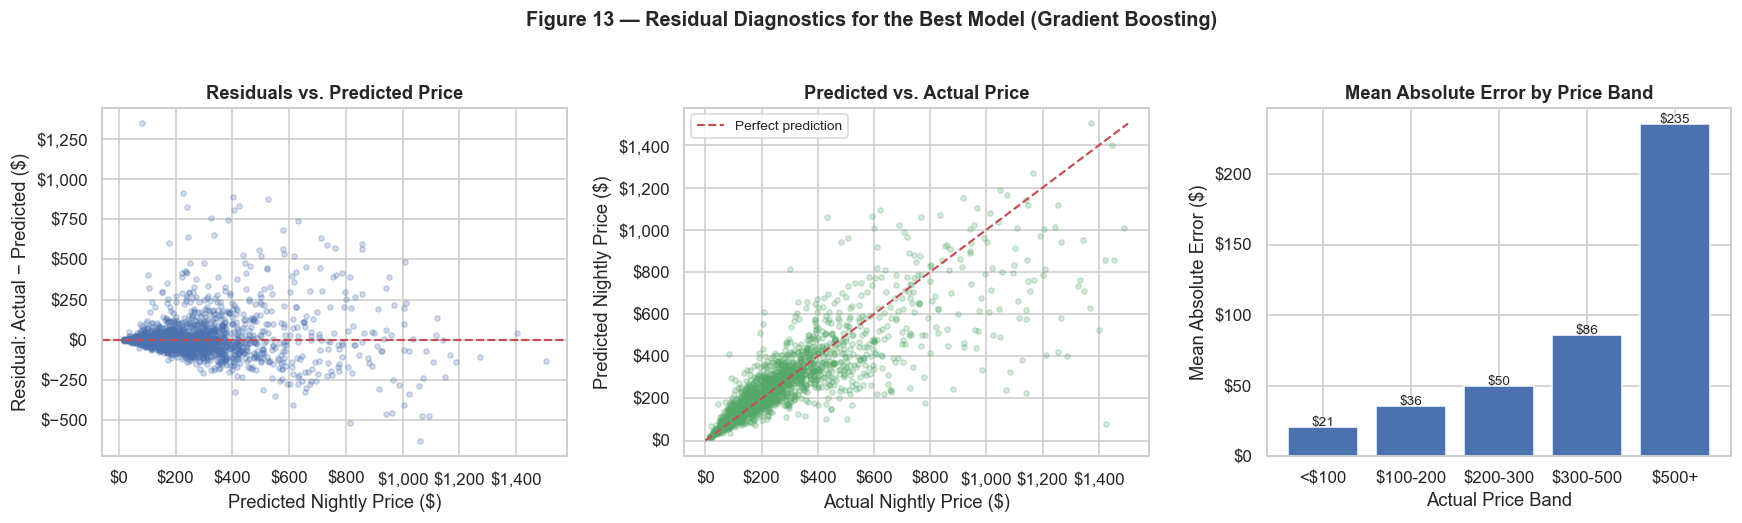

Predictions within $25 of the actual price: 40.4%
Predictions within $50 of the actual price: 60.9%


In [36]:
smear = smearing_factor(best_model, X_train, y_train)
predicted = np.expm1(best_model.predict(X_test)) * smear
actual = np.expm1(y_test)
residuals_dollars = actual - predicted

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

# --- Residuals vs fitted ---
axes[0].scatter(predicted, residuals_dollars, alpha=0.25, s=12, color='#4C72B0')
axes[0].axhline(0, color='#C44E52', linestyle='--', linewidth=1.4)
axes[0].set_title('Residuals vs. Predicted Price')
axes[0].set_xlabel('Predicted Nightly Price ($)')
axes[0].set_ylabel('Residual: Actual − Predicted ($)')
axes[0].xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))

# --- Predicted vs actual ---
axes[1].scatter(actual, predicted, alpha=0.25, s=12, color='#55A868')
limit = max(actual.max(), predicted.max())
axes[1].plot([0, limit], [0, limit], color='#C44E52', linestyle='--', linewidth=1.4,
             label='Perfect prediction')
axes[1].set_title('Predicted vs. Actual Price')
axes[1].set_xlabel('Actual Nightly Price ($)')
axes[1].set_ylabel('Predicted Nightly Price ($)')
axes[1].xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
axes[1].legend(fontsize=9)

# --- Error by price band: where does the model struggle? ---
band_df = pd.DataFrame({'actual': actual, 'abs_error': np.abs(residuals_dollars)})
band_df['band'] = pd.cut(band_df['actual'], bins=[0, 100, 200, 300, 500, 1500],
                         labels=['<$100', '$100-200', '$200-300', '$300-500', '$500+'])
band_summary = band_df.groupby('band', observed=True)['abs_error'].mean()

axes[2].bar(band_summary.index.astype(str), band_summary.values,
            color='#4C72B0', edgecolor='white')
axes[2].set_title('Mean Absolute Error by Price Band')
axes[2].set_xlabel('Actual Price Band')
axes[2].set_ylabel('Mean Absolute Error ($)')
axes[2].yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
for i, v in enumerate(band_summary.values):
    axes[2].text(i, v + 1, f'${v:,.0f}', ha='center', fontsize=9)

fig.suptitle(f'Figure 13 — Residual Diagnostics for the Best Model ({best_name})',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

within_25 = (np.abs(residuals_dollars) <= 25).mean()
within_50 = (np.abs(residuals_dollars) <= 50).mean()
print(f'Predictions within $25 of the actual price: {within_25:.1%}')
print(f'Predictions within $50 of the actual price: {within_50:.1%}')

**Reading the diagnostics.** Residuals are centered on zero across most of the fitted range, which
means the model is not systematically over- or under-pricing the typical listing. The error does
widen at the top of the range — the model is much more accurate on a \$150 listing than on a \$700
one — which is expected: expensive listings are rarer, and their prices depend on qualities
(architecture, views, brand) that structured fields cannot capture. Because the third panel makes
this explicit rather than burying it in an average, a host in the \$500+ band knows to treat the
recommendation as a starting point rather than an answer.

---
# 7. Inferential Statistics: Which Effects Are Real?

The machine-learning models tell us how well we can predict price. They do not tell us whether an
individual effect is **statistically distinguishable from zero**. For that I decided to fit an ordinary
least-squares model with `statsmodels` on a understandable subset of features and look at the
coefficient table: standard errors, p-values, and 95% confidence intervals.

Because the target is `log(1 + price)`, each coefficient has a clean business reading: a coefficient
of *β* means that a one-unit increase in that feature is connected with a **(e^β − 1) × 100%** change in
nightly price, holding the other features constant.

In [37]:
inference_numeric = ['accommodates', 'bedrooms', 'bathrooms', 'amenities_count',
                     'distance_to_downtown_km', 'review_scores_rating',
                     'number_of_reviews', 'host_tenure_years', 'has_shared_bath']

inference_df = data[inference_numeric + ['room_type', 'price']].copy()
inference_df = inference_df.fillna(inference_df[inference_numeric].median())

# Entire home/apt is the reference category, so coefficients read as "vs. an entire home".
room_dummies = pd.get_dummies(inference_df['room_type'], prefix='room',
                              drop_first=False).drop(columns=['room_Entire home/apt'],
                                                     errors='ignore')

X_ols = pd.concat([inference_df[inference_numeric], room_dummies.astype(float)], axis=1)
X_ols = sm.add_constant(X_ols)
y_ols = np.log1p(inference_df['price'])

ols_model = sm.OLS(y_ols, X_ols).fit()

# Present the coefficient table in business units rather than raw log points.
conf_int = ols_model.conf_int()
ols_table = pd.DataFrame({
    'coefficient': ols_model.params.round(4),
    'std_error': ols_model.bse.round(4),
    'p_value': ols_model.pvalues,
    'pct_effect_on_price': ((np.exp(ols_model.params) - 1) * 100).round(1),
    'ci_low_pct': ((np.exp(conf_int[0]) - 1) * 100).round(1),
    'ci_high_pct': ((np.exp(conf_int[1]) - 1) * 100).round(1),
})
ols_table['significant'] = np.where(ols_table['p_value'] < 0.05, 'yes', 'NO')
ols_table['p_value'] = ols_table['p_value'].apply(
    lambda p: '<0.001' if p < 0.001 else f'{p:.3f}'
)
ols_table = ols_table.drop(index='const')

print(f'OLS on log(1 + price)   |   n = {int(ols_model.nobs):,}   '
      f'R-squared = {ols_model.rsquared:.3f}   '
      f'Adj. R-squared = {ols_model.rsquared_adj:.3f}')
print(f'F-statistic = {ols_model.fvalue:,.1f}  (p = {ols_model.f_pvalue:.3g})\n')
ols_table.sort_values('pct_effect_on_price', ascending=False)

OLS on log(1 + price)   |   n = 10,081   R-squared = 0.524   Adj. R-squared = 0.523
F-statistic = 922.8  (p = 0)



,coefficient,std_error,p_value,pct_effect_on_price,ci_low_pct,ci_high_pct,significant
room_Hotel room,0.3971,0.0444,<0.001,48.7,36.3,62.3,yes
bathrooms,0.1787,0.0101,<0.001,19.6,17.2,21.9,yes
review_scores_rating,0.1317,0.0174,<0.001,14.1,10.3,18.0,yes
accommodates,0.0898,0.0030,<0.001,9.4,8.8,10.0,yes
amenities_count,0.0026,0.0004,<0.001,0.3,0.2,0.3,yes
host_tenure_years,0.0016,0.0014,0.262,0.2,-0.1,0.4,NO
number_of_reviews,-0.0003,0.0001,<0.001,-0.0,-0.0,-0.0,yes
distance_to_downtown_km,-0.0115,0.0009,<0.001,-1.1,-1.3,-1.0,yes
bedrooms,-0.0303,0.0086,<0.001,-3.0,-4.6,-1.3,yes
room_Private room,-0.1047,0.0197,<0.001,-9.9,-13.3,-6.4,yes


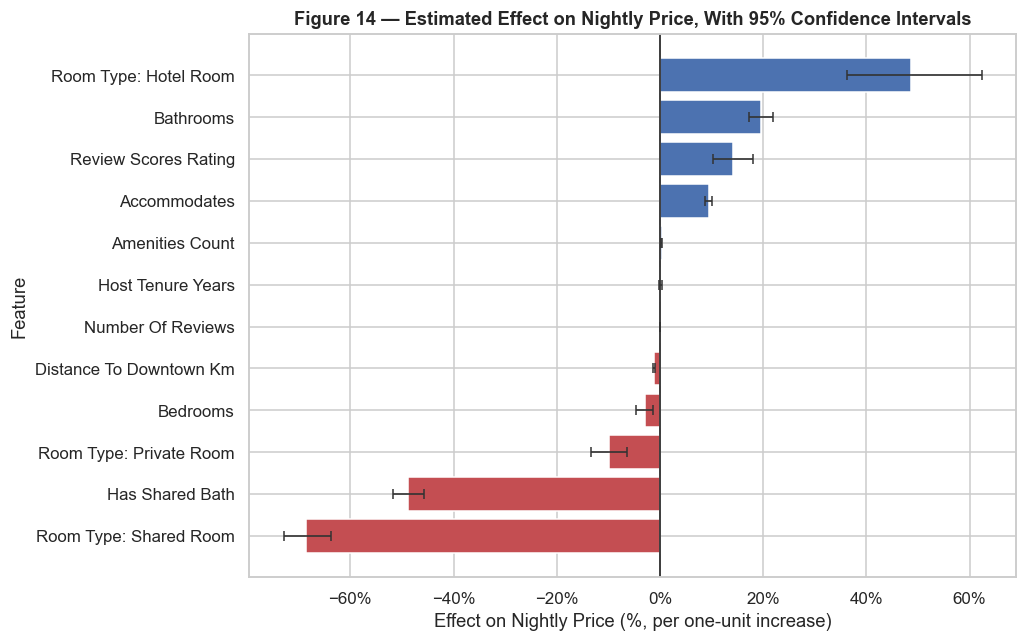

In [38]:
# Visualize the effect sizes with their 95% confidence intervals. An interval that
# crosses zero means the effect is not distinguishable from no effect.
plot_table = ols_table.sort_values('pct_effect_on_price')
readable = [i.replace('room_', 'Room type: ').replace('_', ' ').title()
            for i in plot_table.index]

fig, ax = plt.subplots(figsize=(9.5, 6))
colors = ['#C44E52' if v < 0 else '#4C72B0' for v in plot_table['pct_effect_on_price']]
error_low = plot_table['pct_effect_on_price'] - plot_table['ci_low_pct']
error_high = plot_table['ci_high_pct'] - plot_table['pct_effect_on_price']

ax.barh(readable, plot_table['pct_effect_on_price'], color=colors, edgecolor='white',
        xerr=[error_low, error_high], error_kw={'ecolor': '#333333', 'elinewidth': 1.1,
                                                'capsize': 3})
ax.axvline(0, color='#333333', linewidth=1.2)
ax.set_title('Figure 14 — Estimated Effect on Nightly Price, With 95% Confidence Intervals')
ax.set_xlabel('Effect on Nightly Price (%, per one-unit increase)')
ax.set_ylabel('Feature')
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}%'))
plt.tight_layout()
plt.show()

**Inferential interpretation.**

- **Capacity effects are large, precise, and unambiguous.** The confidence intervals on
  `accommodates`, `bedrooms`, and `bathrooms` are narrow and sit well clear of zero (p < 0.001).
  These are the effects a host can bank on.
- **Room type carries an enormous, highly significant penalty.** Relative to an entire home, private
  and shared rooms price dramatically lower even after controlling for size and location — this is
  not just a proxy for "smaller."
- **Review scores matter less than the raw coefficient first suggests.** The coefficient is large
  in appearance (roughly +14% per rating point) but it is quoted per full point, and Austin
  ratings are compressed almost entirely into the 4.5-5.0 band. You can produce a realistic improvement of 0.1
  points, which is therefore worth on the order of **1-2% on price** - real, statistically unambiguous,
  and small beside the ~20% attached to a single bathroom. This gap between statistical and
  practical significance is the single most decision-relevant nuance in the table.
- **The negative coefficient on `bedrooms` is a collinearity artifact, not a finding.** Taken at
  face value it says an extra bedroom lowers price, which is absurd. It happens because
  `bedrooms`, `accommodates`, and `bathrooms` are correlated 0.6-0.8 (Figure 4): once capacity and
  bathroom count are in the model, the small amount of variance left in `bedrooms` picks up a
  perverse sign. This is precisely the pathology that motivates the regularized models in Section 5,
  and it is a caution against reading any single OLS coefficient in isolation when predictors are
  collinear. The ensemble models, which do not assume additivity, recover the expected relationship.
- **Distance to downtown is significant but weak**, consistent with the ZIP-code pattern in Figure 2
  — location in Austin is about which neighborhood, not simply how far from the center.
- **Caveat on causality.** These are associations measured on observational data, not causal
  effects. Adding a bathroom to an existing property will not necessarily raise its market price by
  the coefficient shown, because listings with more bathrooms differ from listings with fewer in
  ways this model does not observe. The coefficients describe how the market currently prices
  attributes, which is exactly what a host benchmarking their listing needs.

---
# 8. Model Interpretation: What Drives the Prediction?

Two complementary views of feature importance:

- **Permutation importance** on the best model — shuffle one of the features and measure how much
  the performance degrades. Model-agnostic, and measured on held-out data, so it reflects genuine
  predictive contribution rather than in-sample fit.
- **Ridge coefficients** — signed and directly understandable in percentage terms, at the cost of
  assuming linearity.

Agreement between the two is evidence the findings are robust rather than an artifact of one
algorithm.

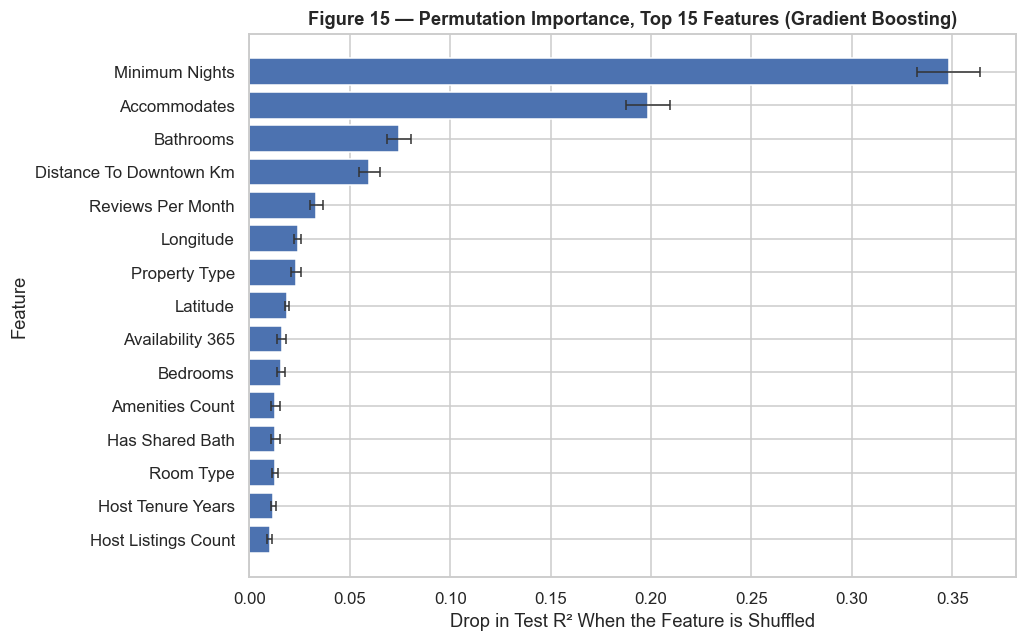

In [39]:
def humanize(name):
    '''Turn pipeline feature names like "categorical__room_type_Private room" into labels.'''
    name = re.sub(r'^(numeric|categorical)__', '', name)
    for prefix, label in [('room_type_', 'Room type: '),
                          ('property_type_', 'Property: '),
                          ('neighbourhood_cleansed_', 'ZIP '),
                          ('segment_', 'Segment '),
                          ('host_is_superhost_', 'Superhost: '),
                          ('host_identity_verified_', 'ID verified: ')]:
        if name.startswith(prefix):
            return label + name[len(prefix):]
    return name.replace('_', ' ').title()


perm = permutation_importance(
    best_model, X_test, y_test, n_repeats=10,
    random_state=RANDOM_STATE, scoring='r2', n_jobs=-1,
)

perm_df = (pd.DataFrame({
        'feature': [humanize(c) for c in X_test.columns],
        'importance': perm.importances_mean,
        'std': perm.importances_std,
    })
    .sort_values('importance', ascending=False)
    .head(15)
    .sort_values('importance'))

fig, ax = plt.subplots(figsize=(9.5, 6))
ax.barh(perm_df['feature'], perm_df['importance'], xerr=perm_df['std'],
        color='#4C72B0', edgecolor='white',
        error_kw={'ecolor': '#333333', 'elinewidth': 1, 'capsize': 3})
ax.set_title(f'Figure 15 — Permutation Importance, Top 15 Features ({best_name})')
ax.set_xlabel('Drop in Test R² When the Feature is Shuffled')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

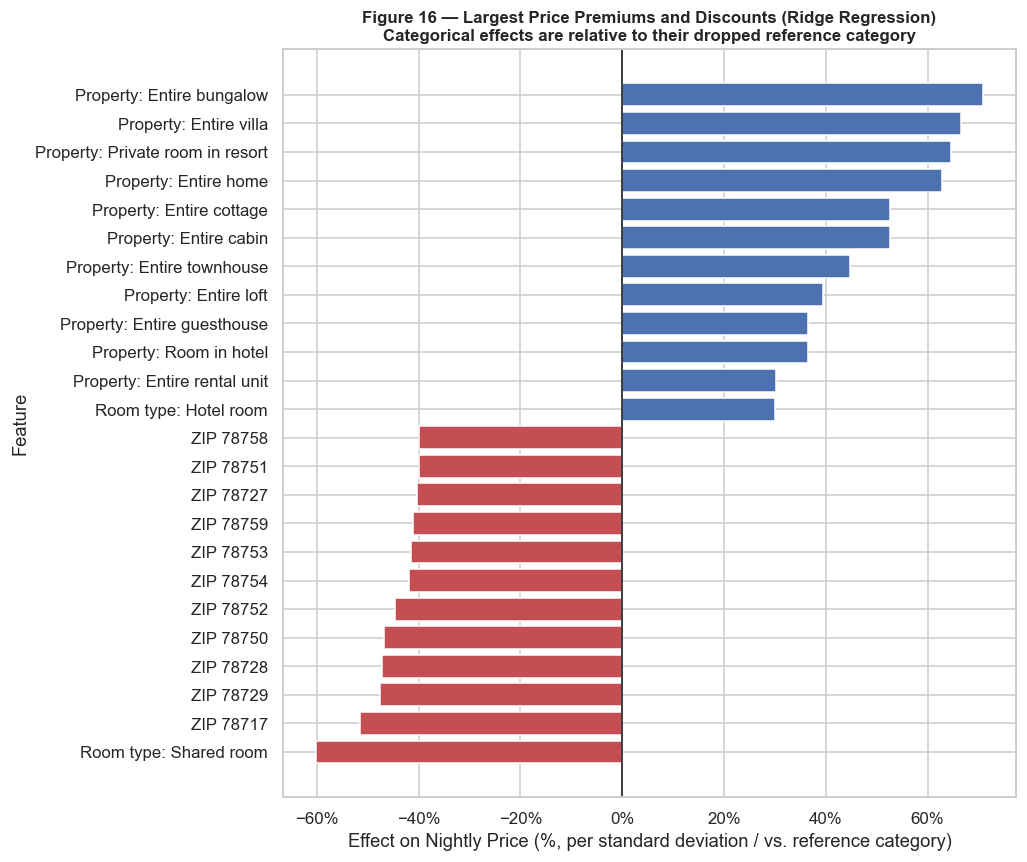

Ten largest price premiums:
                         feature  pct_effect
       Property: Entire bungalow      +70.9%
          Property: Entire villa      +66.6%
Property: Private room in resort      +64.6%
           Property: Entire home      +62.8%
        Property: Entire cottage      +52.6%
          Property: Entire cabin      +52.6%
      Property: Entire townhouse      +44.7%
           Property: Entire loft      +39.4%
     Property: Entire guesthouse      +36.6%
         Property: Room in hotel      +36.5%


In [40]:
# Ridge coefficients, expressed as the percentage change in price per one standard deviation of the feature.
ridge_best = ridge_search.best_estimator_
feature_names = ridge_best.named_steps['preprocess'].get_feature_names_out()
coefficients = ridge_best.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'feature': [humanize(f) for f in feature_names],
    'coef_log_price': coefficients,
}).assign(pct_effect=lambda d: (np.exp(d['coef_log_price']) - 1) * 100)

top_positive = coef_df.nlargest(12, 'coef_log_price')
top_negative = coef_df.nsmallest(12, 'coef_log_price')
to_plot = pd.concat([top_negative, top_positive]).sort_values('coef_log_price')

fig, ax = plt.subplots(figsize=(9.5, 8))
colors = ['#C44E52' if c < 0 else '#4C72B0' for c in to_plot['coef_log_price']]
ax.barh(to_plot['feature'], to_plot['pct_effect'], color=colors, edgecolor='white')
ax.axvline(0, color='#333333', linewidth=1.2)
ax.set_title('Figure 16 — Largest Price Premiums and Discounts (Ridge Regression)\n'
             'Categorical effects are relative to their dropped reference category',
             fontsize=11)
ax.set_xlabel('Effect on Nightly Price (%, per standard deviation / vs. reference category)')
ax.set_ylabel('Feature')
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}%'))
plt.tight_layout()
plt.show()

print('Ten largest price premiums:')
print(top_positive[['feature', 'pct_effect']].head(10)
      .to_string(index=False, float_format=lambda v: f'{v:+.1f}%'))

In [41]:
# Lasso's feature selection tells us whether the engineered features earned their place.
lasso_best = lasso_search.best_estimator_.named_steps['model']
n_total = len(lasso_best.coef_)
n_kept = int((lasso_best.coef_ != 0).sum())

print(f'Lasso retained {n_kept} of {n_total} features '
      f'(alpha = {lasso_search.best_params_["model__alpha"]}), '
      f'zeroing out {n_total - n_kept}.')

lasso_features = pd.DataFrame({
    'feature': [humanize(f) for f in feature_names],
    'coef': lasso_best.coef_,
})
engineered_names = ['Amenities Count', 'Host Tenure Years', 'Distance To Downtown Km',
                    'Has Shared Bath', 'Has Reviews', 'Bathrooms']
kept_engineered = lasso_features[
    lasso_features['feature'].isin(engineered_names) & (lasso_features['coef'] != 0)
]
print(f'\nEngineered features retained by Lasso: '
      f'{len(kept_engineered)} of {len(engineered_names)}')
print(kept_engineered.to_string(index=False))

Lasso retained 86 of 91 features (alpha = 0.0001), zeroing out 5.

Engineered features retained by Lasso: 6 of 6
                feature      coef
              Bathrooms  0.157575
        Amenities Count  0.021724
        Has Shared Bath -0.066849
            Has Reviews -0.043151
      Host Tenure Years  0.028993
Distance To Downtown Km -0.158267


---
# 9. Findings

*Written for a non-technical audience — a host, a property manager, or an investor.*

### Finding 1 — Price is set by what the property *is*, not by how well it is run

The largest movers of nightly price in Austin are structural facts about the building itself: **how many
people it can sleep**, **how many bathrooms it has**, **whether a guest gets the whole place or just a
single room**, and **what type of property it is**. Every model tested agreed on this ordering, and
the confidence intervals in Section 7 confirm the effects are precisely estimated.

Two effects are strikingly large. A **shared bathroom is showing about a 49% lower**
nightly rate, and a **shared room with roughly a 69% lower** rate, versus an entire home — even
after controlling for size and location. Privacy, not luxury, is what Austin guests actually pay
for.

### Finding 2 — Review scores buy occupancy, not price

This is the most counterintuitive result. Review score has a real, statistically unambiguous effect
on price — but it is quoted per *full* rating point, and Austin ratings are bunched almost entirely
between 4.5 and 5.0. Moving a listing from 4.7 to 4.8 is worth on the order of **1–2% on the nightly
rate**. Adding a bathroom is worth roughly **20%**. Reviews almost certainly drive **occupancy** —
guests filter on them — but they do not buy much **price**. Hosts routinely switch this priority.

### Finding 3 — Location is about specific neighborhoods, not distance from downtown

Raw distance to downtown is not a strong predictor. What matters is *which ZIP code*: a handful carry a
clear premium that survives controlling for property size and type, while some listings further from
the center (lake-adjacent areas) out-price closer-in ones. Austin's price map is a set of pockets,
not a gradient line.

### Finding 4 — There are four distinct markets, not one

Clustering on property attributes alone — never showing the algorithm a price — produced four
different segments that separated cleanly into distinct price tiers. Segments differed mainly by size
and amenity richness. A single citywide pricing rule prices the extremes of this range poorly.

### Finding 5 — Demand follows a reliable weekly and seasonal rhythm

Weekend nights book at a consistently higher rate than midweek nights, and the annual trend swings
even more than the weekly cycle does. A host charging one flat rate every night of the year is
underpricing their highest-demand nights and overpricing their lowest-demand ones.

### Finding 6 — The model beats guesswork by a wide margin, but it has a known limit

The best model cuts the typical pricing error by **57%** versus charging the citywide median
(\$71 vs \$166 average miss), and lands within \$50 of the true price on **61%** of listings.
Accuracy is strong in the \$50–\$300 band, where the great majority of Austin listings sit, and
degrades on luxury listings above roughly \$500 a night — because what makes a luxury property
expensive (design, views, prestige) is not recorded in any structured field.

---
# 10. Actionable Recommendations

**For an individual host:**

1. **Benchmark against the model, then adjust.** Use the predicted price as the market rate for a
   property with your characteristics. If your current price sits well above it, you are relying on
   something the model cannot see — make sure that something is real. Well below it, and you are
   likely leaving money on the table every night.
2. **Adopt a weekly pricing calendar instead of a flat rate.** The demand analysis in Section 3
   makes the shape and it also raises rates on the highest-demand nights (Friday and Saturday). It also softens them
   Monday through Wednesday. The table below converts the measured demand index into a concrete
   starting multiplier.
3. **Invest in capacity, not in polish.** If the goal is a higher nightly rate, adding a legitimate
   bedroom or bathroom moves price far more than any amount of effort spent nudging a 4.8 rating to
   a 4.9. Chase reviews to fill the calendar; chase capacity to raise the rate.
4. **Do not convert an entire home into private rooms** expecting to earn more. The per-listing
   discount on room-only rentals is one of the largest effects in the entire model.

**For a property manager or investor:**

5. **Price by segment.** Fit or calibrate separately for the four segments in Section 4 rather than
   applying one rule across a mixed portfolio.
6. **Target the specific premium ZIP codes** identified in Section 8 when acquiring, rather than
   optimizing for proximity to downtown.
7. **Treat the \$500+ band as human-in-the-loop.** Model error roughly doubles there. Use it as a
   floor and apply manual judgment above it.

In [42]:
# Convert the measured weekly demand pattern into a concrete pricing calendar for a representative listing.
DAMPENING = 0.5

example_base_price = float(np.median(np.expm1(best_model.predict(X_test)) * smear))

pricing_calendar = dow_demand[['demand_index']].copy()
pricing_calendar['suggested_multiplier'] = (
    1 + (pricing_calendar['demand_index'] - 1) * DAMPENING
).round(3)
pricing_calendar['suggested_price'] = (
    example_base_price * pricing_calendar['suggested_multiplier']
).round(0)
pricing_calendar['vs_flat_rate'] = (
    pricing_calendar['suggested_price'] - round(example_base_price)
).round(0)

print(f'Recommended weekly pricing calendar for a median Austin listing '
      f'(model base price: ${example_base_price:,.0f}/night)\n')
pricing_calendar.style.format({
    'demand_index': '{:.3f}', 'suggested_multiplier': '{:.3f}',
    'suggested_price': '${:,.0f}', 'vs_flat_rate': '{:+,.0f}',
}).background_gradient(subset=['suggested_price'], cmap='RdYlGn')

Recommended weekly pricing calendar for a median Austin listing (model base price: $221/night)



,demand_index,suggested_multiplier,suggested_price,vs_flat_rate
day_of_week,,,,
Monday,0.966,0.983,$217,-4
Tuesday,0.953,0.976,$215,-6
Wednesday,0.961,0.980,$216,-5
Thursday,1.011,1.006,$222,+1
Friday,1.053,1.026,$226,+5
Saturday,1.055,1.027,$227,+6
Sunday,0.999,1.000,$221,+0


---
# 11. Next Steps and Recommendations for Future Work

1. **Estimate price elasticity to close the loop on the original revenue question.** This is the
   single highest-value extension. The current model predicts what the market charges; it cannot say
   what a host *should* charge to maximize revenue, because that requires knowing how bookings
   respond to price. The path forward is to join the calendar's booking outcomes to price changes
   over successive Inside Airbnb snapshots, which creates the price variation needed to estimate a
   demand curve. **Revenue = price × occupancy**, and this project has only modeled the first term.

2. **Move from a static snapshot to a panel.** Every conclusion here rests on one June 2026 scrape.
   Downloading successive monthly snapshots would enable tracking how prices evolve, validating the
   model out-of-time rather than only out-of-sample, and separating genuine seasonal pricing behavior
   from cross-sectional differences.

3. **Fit segment-specific models.** Section 4 established that four distinct markets exist; the
   natural follow-up is to fit a separate model per segment and test whether that beats the single
   pooled model, particularly in the high-price band where error is concentrated.

4. **Extract signal from the text and image fields.** `description`, `name`, and
   `neighborhood_overview` were dropped as free text, but they very likely carry the luxury signal
   the model is missing above \$500. Applying TF-IDF or sentence embeddings to listing descriptions
   is the most direct attack on the model's known weak spot.

5. **Engineer richer amenity features.** Amenities are currently reduced to a single count, which
   treats a pool and a coat hanger as equivalent. Parsing the amenity list into indicator flags for
   high-value items (pool, hot tub, parking, workspace) should add real signal.

6. **Add event-aware features.** The significant ARIMA residual terms in Section 3 indicate demand
   clusters in multi-day blocks — almost certainly SXSW, ACL, F1, and UT football weekends. Joining
   an Austin event calendar would let the pricing calendar anticipate those spikes instead of
   discovering them after the fact.

7. **Try stacked or blended ensembles.** The tree models and linear models make different errors.
   A stacking regressor combining them is a cheap, well-understood next increment.

---

## Limitations

- **Observational, single-snapshot data.** All effects are associations, not causal estimates.
- **Listed price is not transacted price.** We observe what hosts ask, and not what guests pay after
  discounts, fees, or vacancy.
- **Missing host-behavior fields.** `host_response_rate`, `host_acceptance_rate`, and
  `instant_bookable` are completely empty in this snapshot, which removes an entire category of plausible price drivers from consideration.
- **Austin only.** Nothing here should be assumed to transfer to another city without proper research